# 4.1 — inspect the HMM fits

Per-session segmentations and summary statistics for whatever `4.0_hmm_fit.ipynb` has
produced. **Nothing here refits** — the decoded states are in the pickles, so this runs in
seconds and works while a fitting job is still going.

Panels are variable-aware: whisker ME is drawn as a trace, lick counts as event ticks,
because a count series plotted as a line is unreadable at 60 Hz.

All plotting lives in `hmm_plots.py`.

In [1]:
""" IMPORTS """
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hmm_functions as H
import hmm_plots as P

%matplotlib inline

ERROR:2026-09-04 16:21:56,850:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


## Configuration — must match the run you want to look at

In [18]:
# ==========================================================================
#                                RUN CODE
# ==========================================================================

prefix = '/home/ines/repositories/representation_learning_variability/'

# ---- WHICH DATA -------------------------------------------------------------
data_path = prefix + 'paper-individuality/data/design_matrices/'
data_path = prefix + 'paper-individuality/data/design_matrices/1_camera_setup/NM/'  # session_1
# data_path = prefix + 'paper-individuality/data/design_matrices/1_camera_setup/extra_bwm/'

fps = 60.0        # 60 for the two-camera set, 30 for the 1_camera_setup / training sets
fps = 30.0

# same block as in 5.0 -- keep these in step
VARIABLES = [
    dict(var='whisker_me', model='gaussian', zsc=True,  method='kmeans'),
    dict(var='Lick count', model='poisson',  zsc=False, method='prior'),
]
num_states = 2
num_train_batches = 5
fit_method = 'em'
kappa = 0.0
min_dwell_ms = 167.

# ---- BIN COARSENESS -- MUST MATCH THE RUN YOU WANT TO LOOK AT ---------------
# Same meaning and same units as in 4.0_hmm_fit: milliseconds, per variable, None for
# the native frame rate. It selects the directory (the tag carries the bin width), so a
# mismatch here does not silently show you the wrong fits -- the folder simply is not
# there and the session count comes back 0.
BIN_MS = {'whisker_me': None,
          'Lick count': 100} #100.0
# BIN_MS = 100.0        # a single number applies to every variable
# BIN_MS = None         # everything at the native frame rate

def bin_frames_for(var):
    ms = BIN_MS.get(var) if isinstance(BIN_MS, dict) else BIN_MS
    return 1 if not ms else max(1, int(round(float(ms) * fps / 1000.0)))

# an external duration reference, where one exists. For whisker ME the model-free
# changepoint duration is ~450 ms (IQR 379-550); there is no such anchor for licking.
ANCHOR = {'whisker_me': 450.}

def paths_for(spec):
    k = bin_frames_for(spec['var'])
    binpart = '' if k == 1 else f"_bin{k*1000.0/fps:.0f}ms"
    tag = f"{num_train_batches}_{spec['model']}_{spec['method']}_{fit_method}_" \
          f"zsc_{spec['zsc']}_k{int(kappa)}_s{num_states}{binpart}/"
    save = prefix + 'paper-individuality/data/hmm/fits/' + tag
    save = prefix + 'paper-individuality/data/neuromodulators/hmm/fits/' + tag
    csv = os.path.join(save, f"assessments_{spec['var']}.csv")
    return save, csv

for spec in VARIABLES:
    save_path, csv_path = paths_for(spec)
    k = bin_frames_for(spec['var'])
    width = 'native frames' if k == 1 else f"{k} fr = {k*1000.0/fps:.0f} ms"
    n = len(P.available_sessions(save_path, spec['var'])) if os.path.exists(save_path) else 0
    flag = '' if n else '   <-- nothing here; check BIN_MS / fps / data_path'
    print(f"  {spec['var']:14s} {spec['model']:10s} {width:16s} {n:4d} fits   {save_path}{flag}")

  whisker_me     gaussian   native frames      91 fits   /home/ines/repositories/representation_learning_variability/paper-individuality/data/neuromodulators/hmm/fits/5_gaussian_kmeans_em_zsc_True_k0_s2/
  Lick count     poisson    3 fr = 100 ms      91 fits   /home/ines/repositories/representation_learning_variability/paper-individuality/data/neuromodulators/hmm/fits/5_poisson_prior_em_zsc_False_k0_s2_bin100ms/


## Which sessions are finished

In [19]:
# pick the variable to inspect
spec = VARIABLES[1]
var, model = spec['var'], spec['model']
save_path, csv_path = paths_for(spec)

sessions_available = P.available_sessions(save_path, var)
print(f'Found {len(sessions_available)} finished sessions for {var} ({model}).')

# rebuilt from the pickles, so it is complete even if the run was interrupted
df = H.assessments_from_pickles(save_path, var)
cols = [c for c in ['mouse','eid','n_frames','n_segments','median_dwell_ms',
                    'occupancy_state1','level_low','level_high','raw_ll_per_frame',
                    'bits_LL','fit_ok'] if c in df]
df[cols]

Found 91 finished sessions for Lick count (poisson).


,mouse,eid,n_frames,n_segments,median_dwell_ms,occupancy_state1,level_low,level_high,raw_ll_per_frame,bits_LL,fit_ok
0,ZFM-03059,10e13954-53dd-4a07-86bd-9bff46459efc,28610,617,1500.0,0.0934,0.000228,1.801556,-0.226153,0.201535,True
1,ZFM-03059,18381ae9-05fe-4eb8-8c27-fd1d8d1cb0bf,27065,173,2200.0,0.0364,0.000121,1.625402,-0.086631,0.214396,True
2,ZFM-03059,e1726190-2e94-44ca-afd5-5a355782528b,30645,346,1800.0,0.0670,0.000917,2.289655,-0.162901,0.207967,True
3,ZFM-03447,141cd1ec-1ed3-4407-886f-0d6240c80988,48495,275,2800.0,0.0338,0.000062,0.521601,-0.058172,0.210236,True
4,ZFM-03447,ba8fc80a-e374-4900-ba8a-ad3b244c5bea,45520,440,1900.0,0.0389,0.000362,1.102004,-0.101422,0.201561,True
...,...,...,...,...,...,...,...,...,...,...,...
86,ZFM-09768,3b55dd6c-3708-4657-898a-93de1660019e,46445,1315,1500.0,0.1671,0.000013,1.885111,-0.369413,0.203130,True
87,ZFM-09768,a57d5676-8836-4940-97e2-e4cd1a44976a,35745,994,1600.0,0.1367,0.000007,1.007894,-0.276546,0.198090,True
88,ZFM-09768,f4df73a0-2758-4eaf-9666-1e71b13cf95c,49670,1167,1800.0,0.1440,0.000012,1.383375,-0.300790,0.201331,True
89,ZFM-09772,5bec164a-3eae-4097-9992-a99c62201d53,33225,838,1150.0,0.0691,0.000013,0.508531,-0.150955,0.189439,True


## Summary statistics of the fits

Each panel answers one question. Note that **low `bits_LL` does not imply a bad
segmentation** — the screens are independent, which is why all three are checked.

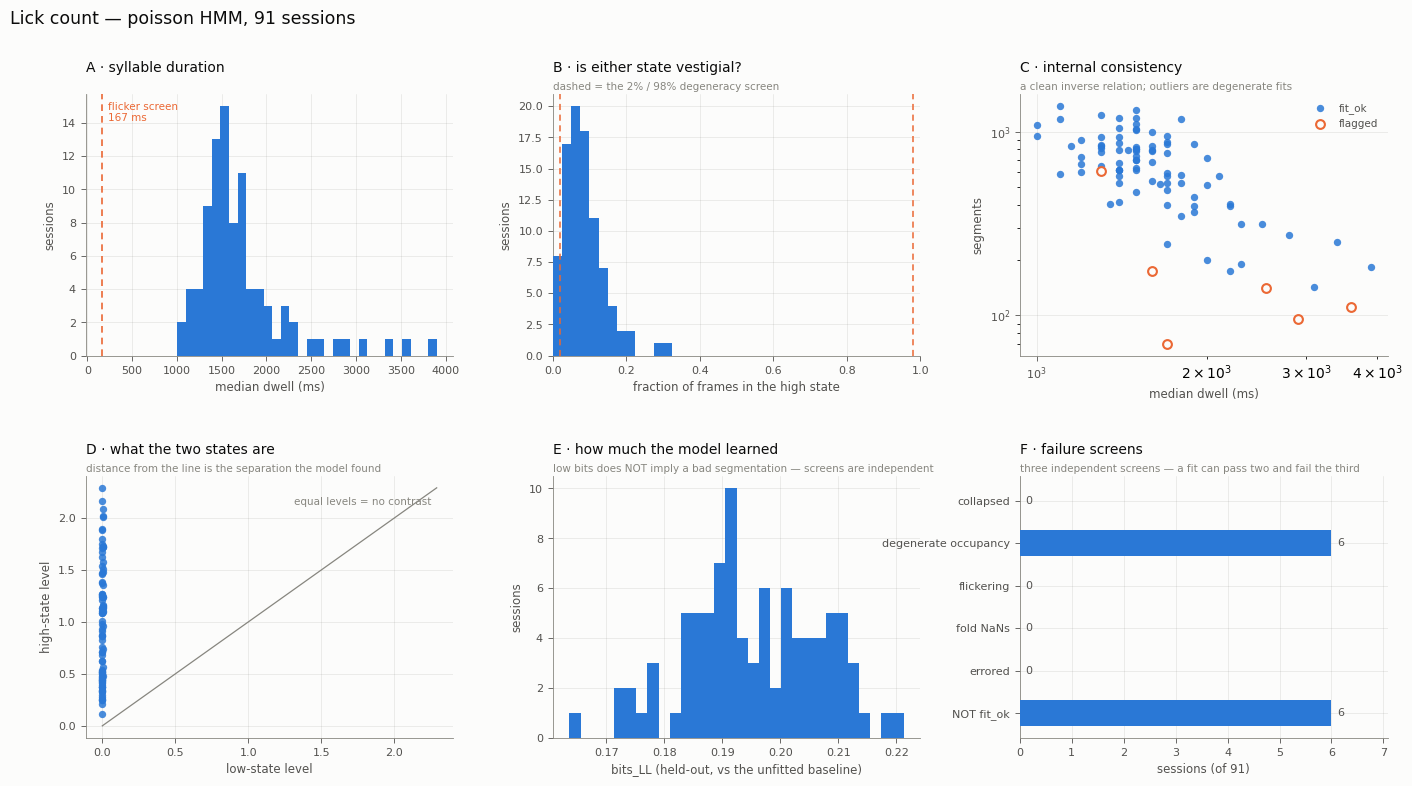

                  count          mean          std           min           25%           50%           75%           max
n_frames           91.0  36705.219780  9395.268074  24995.000000  30077.500000  33200.000000  40827.500000  67500.000000
n_segments         91.0    655.747253   305.011898     70.000000    428.000000    649.000000    840.000000   1385.000000
median_dwell_ms    91.0   1693.956044   537.371957   1000.000000   1400.000000   1500.000000   1800.000000   3900.000000
occupancy_state1   91.0      0.086044     0.057580      0.003300      0.042550      0.076500      0.112800      0.322400
level_low          91.0      0.000914     0.001397      0.000006      0.000017      0.000302      0.001200      0.006675
level_high         91.0      0.980716     0.551344      0.118313      0.472976      0.959836      1.367236      2.289655
raw_ll_per_frame   91.0     -0.183840     0.109235     -0.631564     -0.237130     -0.167271     -0.098588     -0.012783
bits_LL            91.0      0.1

In [20]:
fig = P.plot_summary(df, var, fps=fps, target_dwell_ms=ANCHOR.get(var),
                    min_dwell_ms=min_dwell_ms)
plt.show()

print(df[[c for c in ['n_frames','n_segments','median_dwell_ms','occupancy_state1',
                      'level_low','level_high','raw_ll_per_frame','bits_LL']
          if c in df]].describe().T.to_string())

In [21]:
# per-mouse consistency: does a mouse segment the same way across its own sessions?
per_mouse = P.per_mouse_summary(df)
display(per_mouse)

multi = per_mouse[per_mouse.n >= 2]
if len(multi):
    print(f'{len(multi)} mice with >=2 sessions   |   '
          f'median within-mouse dwell spread {multi.dwell_spread.median():.0f} ms   |   '
          f'between-mouse SD of median dwell {multi.dwell_ms.std():.0f} ms')

,n,dwell_ms,dwell_spread,occupancy,bits,flagged
mouse,,,,,,
ZFM-04019,14,1600.0,1600.0,0.07165,0.196158,2
ZFM-04022,11,1700.0,2400.0,0.05520,0.206808,1
ZFM-08871,11,1400.0,2400.0,0.08210,0.191915,1
ZFM-09394,10,1400.0,900.0,0.09230,0.184536,0
ZFM-09343,6,1400.0,900.0,0.18010,0.181073,0
ZFM-04026,5,1700.0,400.0,0.02910,0.205414,2
ZFM-08813,5,1500.0,800.0,0.08070,0.191705,0
ZFM-03447,4,2550.0,1200.0,0.03525,0.211659,0
ZFM-09768,4,1550.0,400.0,0.14035,0.199710,0


15 mice with >=2 sessions   |   median within-mouse dwell spread 800 ms   |   between-mouse SD of median dwell 366 ms


## One session

Give an **eid** — the 8-character prefix is enough, the mouse is looked up for you — and
optionally `start_s` to move the window elsewhere in the session. Rerun with a different
`start_s` to walk through the recording.

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

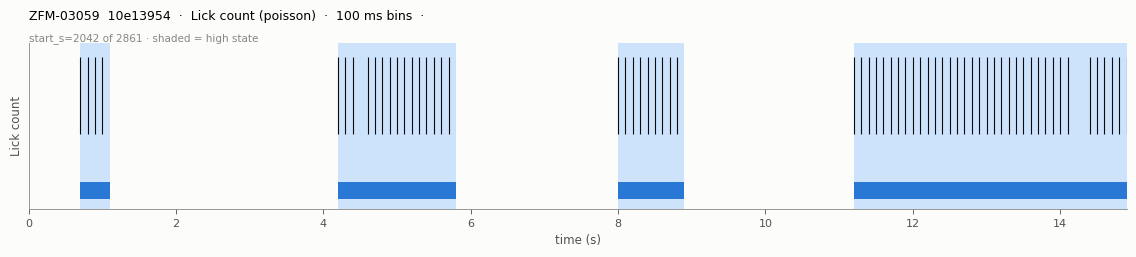

poisson HMM · Lick count · 10e13954-53dd-4a07-86bd-9bff46459efc
  session length   15.9 min
  fold used        4   (per-fold held-out LL: [-0.2019 -0.312  -0.254  -0.2635 -0.0994])
  emission levels  [2.0000e-04 1.8016e+00]
  dwell            1500 ms median, 1546 ms mean over 617 segments
  occupancy        0.093 in the high state


In [22]:
# plot_session reads bin_frames out of the fit's own config, coarsens the signal to
# match and scales the time axis by fps/bin_frames -- so nothing extra to pass here.
eid = df.iloc[0]['eid']
start_s = None      # None = auto-pick an informative window; or e.g. 1200 for 20 min in
win_s = 15

fig, d = P.plot_session(save_path, data_path, var, eid=eid,
                        num_train_batches=num_train_batches, fps=fps,
                        win_s=win_s, start_s=start_s)
plt.show()

a = d['assessment']
print(f"{d['config']['model']} HMM · {var} · {eid}")
print(f"  session length   {len(d['most_likely_states']) / fps / 60:.1f} min")
print(f"  fold used        {d['use_fold']}   (per-fold held-out LL: "
      f"{np.round(np.asarray(d['all_lls']), 4)})")
print(f"  emission levels  {np.round(d['emission_levels'].ravel(), 4)}")
print(f"  dwell            {a['median_dwell_ms']:.0f} ms median, "
      f"{a['mean_dwell_frames'] * 1000 / fps:.0f} ms mean over {a['n_segments']:,} segments")
print(f"  occupancy        {a['occupancy_state1']:.3f} in the high state")

## Several sessions in a row

Set `only_flagged = True` for the ones that failed a screen — that is the list worth going
through by eye.

showing 91 of 91
10e13954-53dd-4a07-86bd-9bff46459efc


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

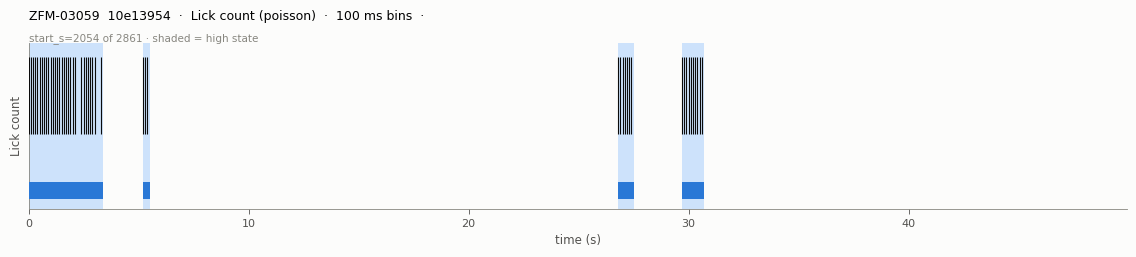

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

18381ae9-05fe-4eb8-8c27-fd1d8d1cb0bf


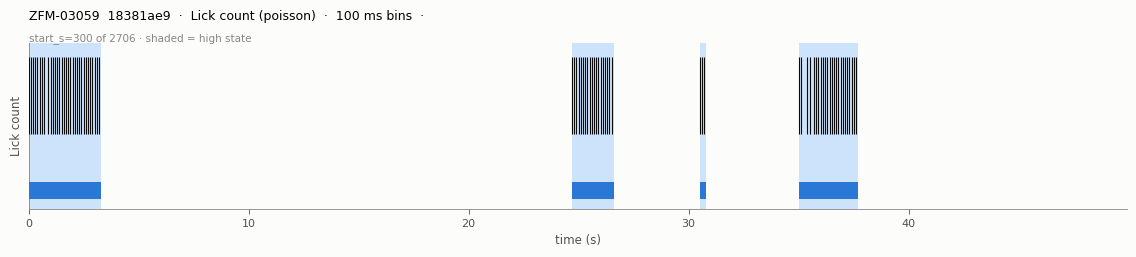

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

e1726190-2e94-44ca-afd5-5a355782528b


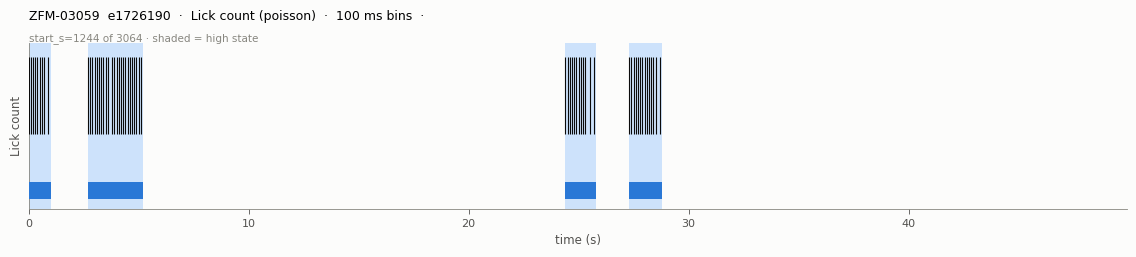

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

141cd1ec-1ed3-4407-886f-0d6240c80988


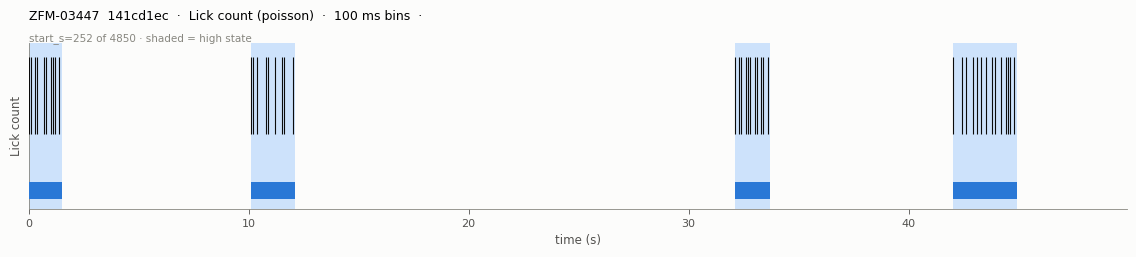

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

ba8fc80a-e374-4900-ba8a-ad3b244c5bea


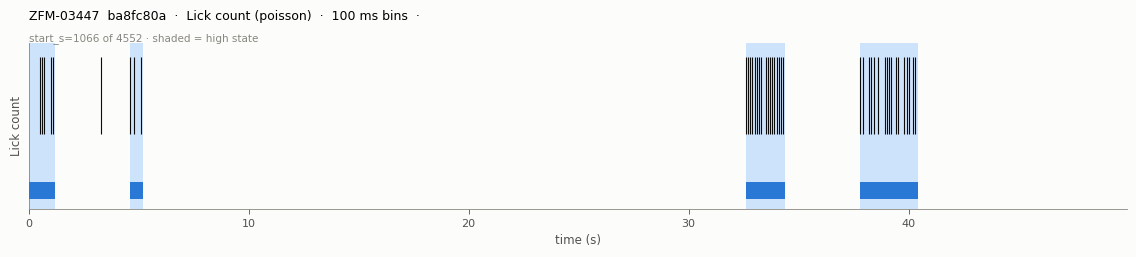

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

c7ce2f64-2e74-4b39-9c32-bb72cba922c1


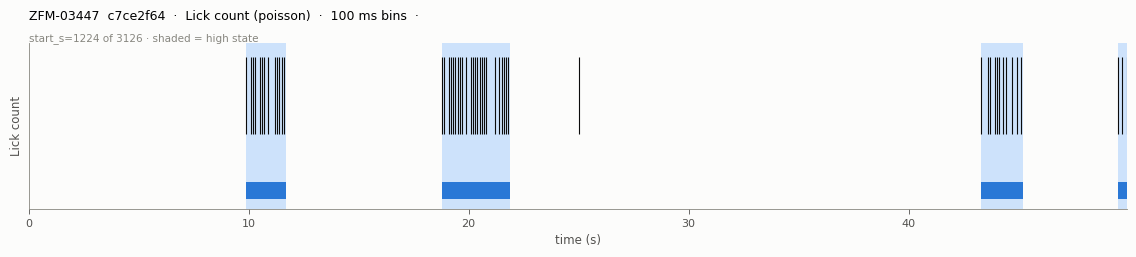

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

f2898cc0-6bfd-4af9-bdc8-58af869dd0be


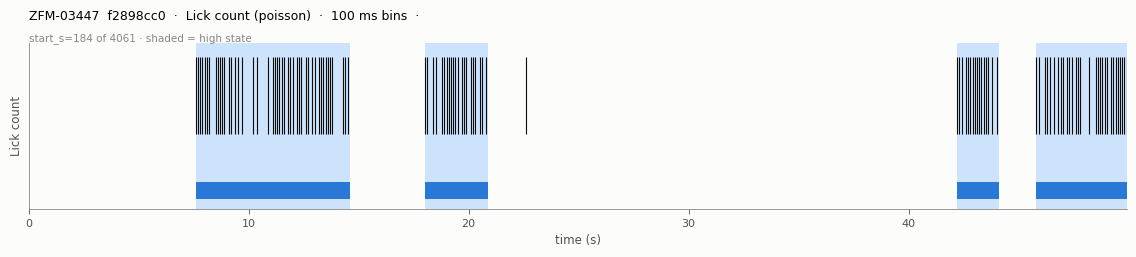

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

04482c20-f984-4d90-97d6-6791bae1e6f7


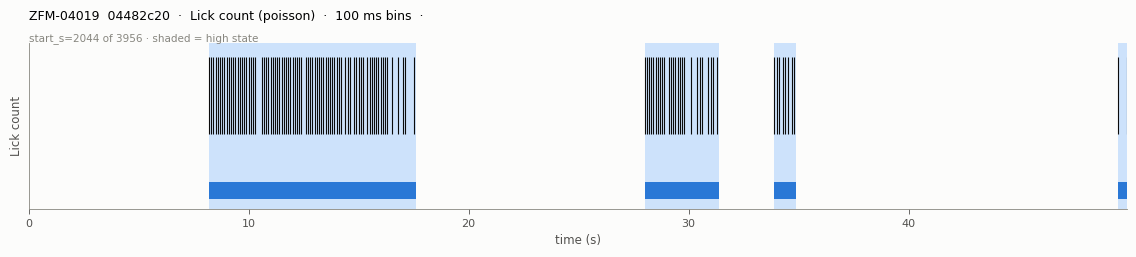

0f41a88d-6746-4754-b8da-2992dcfcb55d


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

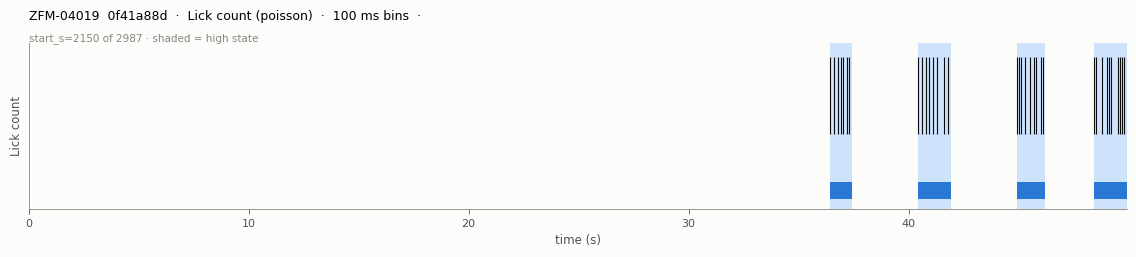

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

1c9d6859-0acd-4e41-9def-a9a08384c18f


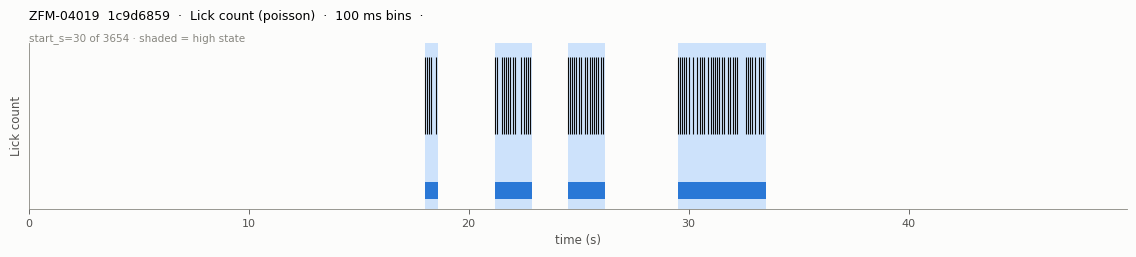

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

2252b3ed-f900-4509-bf77-37d47b56da7a


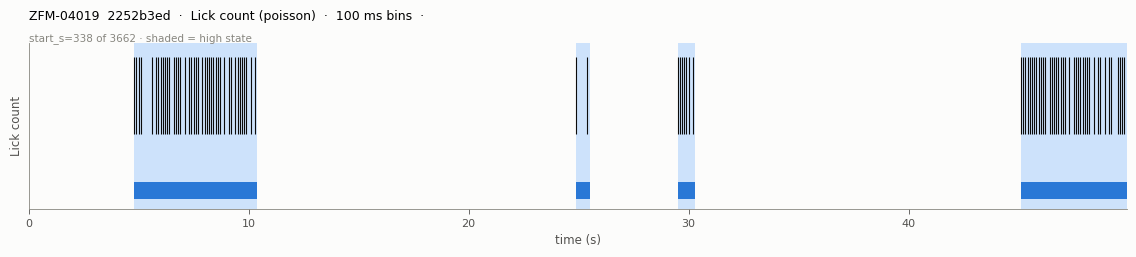

28b2a170-5e33-49c9-9df5-3098c92a7905


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

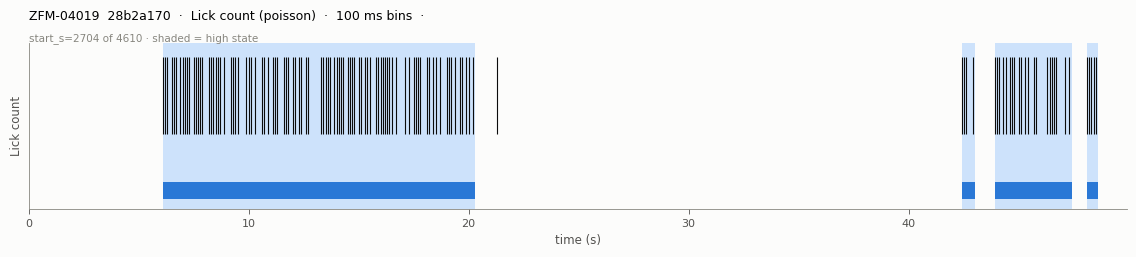

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

2d2e9a22-683a-409c-91e8-79196e10be93


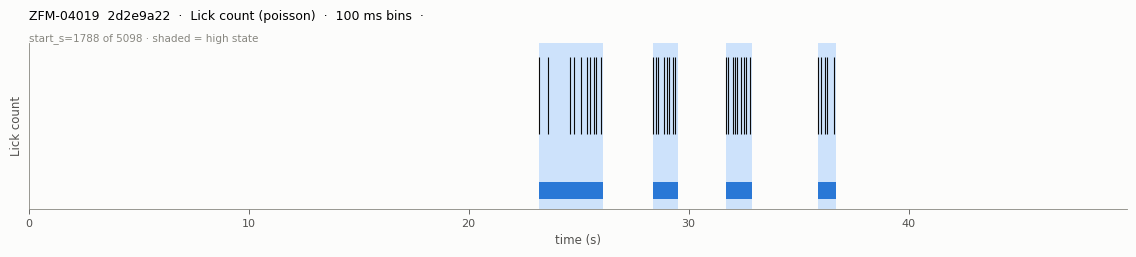

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

41cc34ab-deda-480b-b957-380abb2117c0


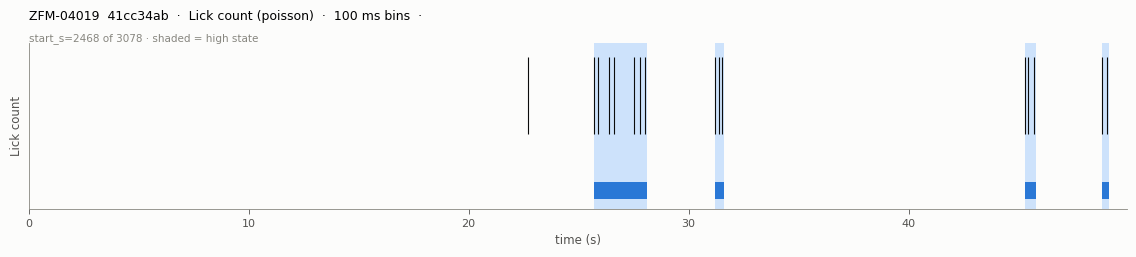

4f585aa9-ada0-4e2e-90d4-2542e5dbf782


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

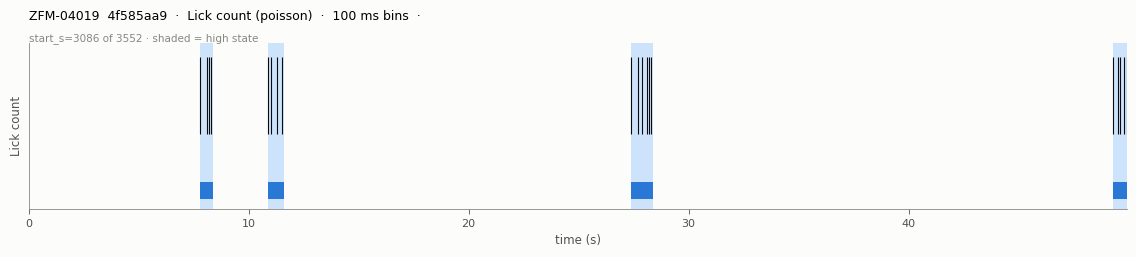

4f7ee34f-71d7-4054-88e6-ff1179762461


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

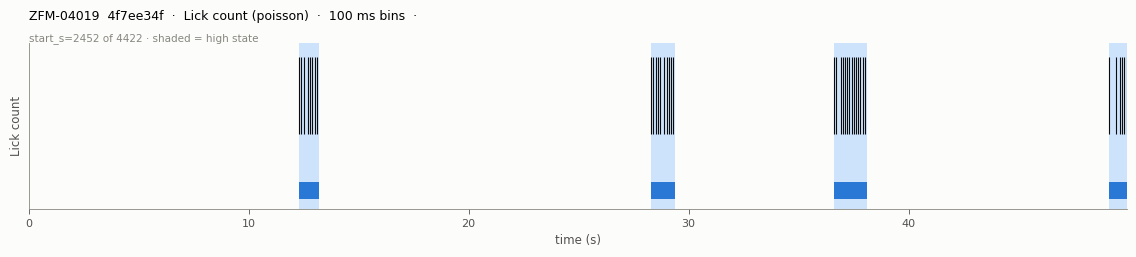

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

5c179d07-235c-4673-87d2-d961f0139140


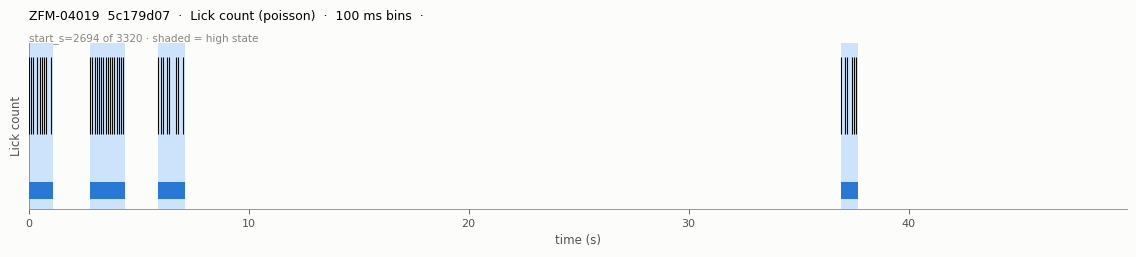

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

699dc94d-e141-42d7-afa5-ab9a1fa000f8


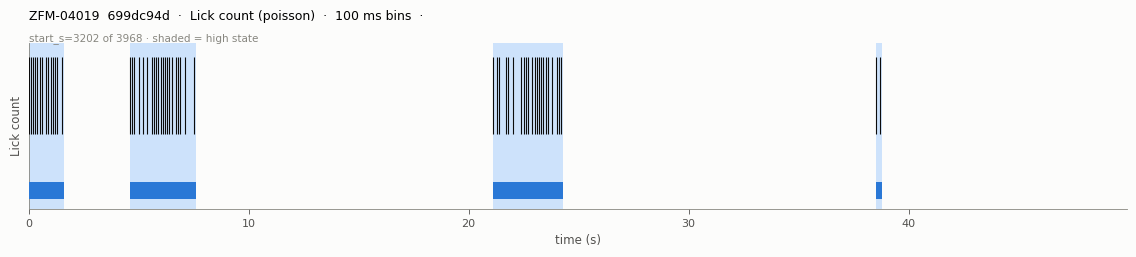

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

80bcab5a-20fd-4cc5-8a0e-e1e0149da372


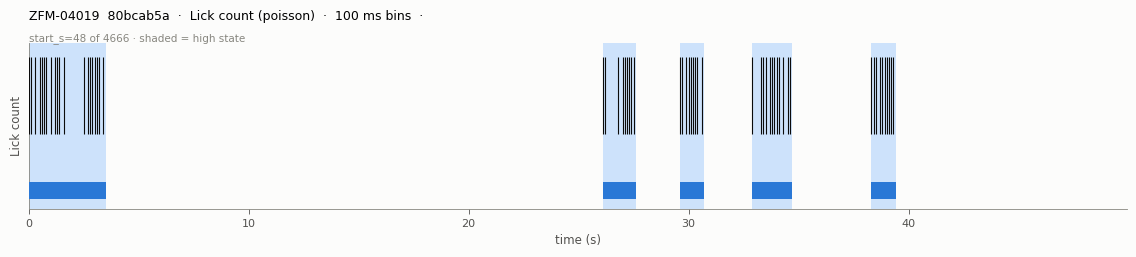

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

aa211f0c-94df-4f8a-9775-b8fcec3f5138


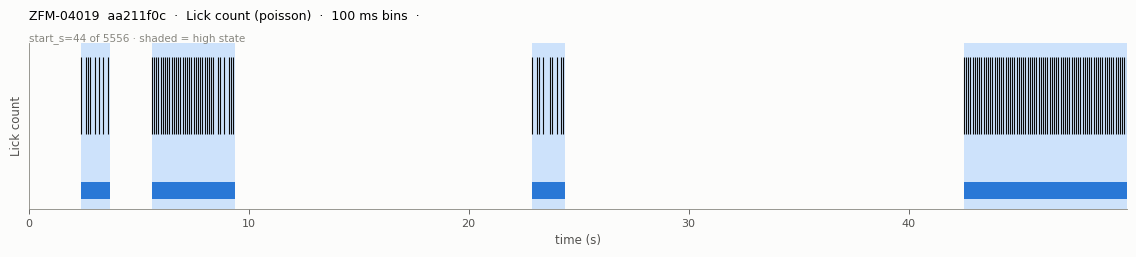

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

f24c2389-1716-4827-a14c-3a11dee6a754


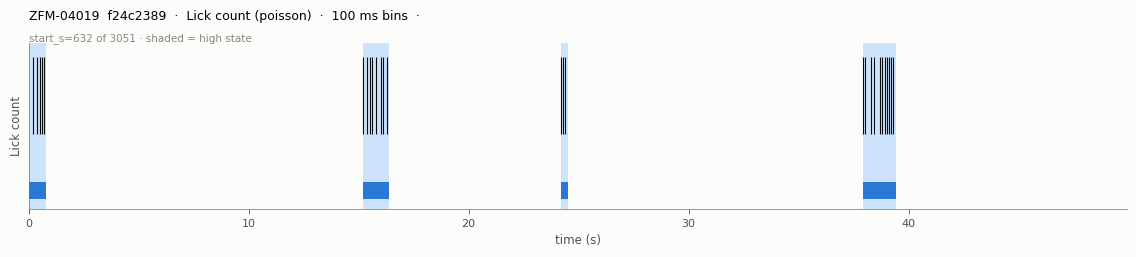

173b48e4-8201-44f5-8c36-7886afcd82e2


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

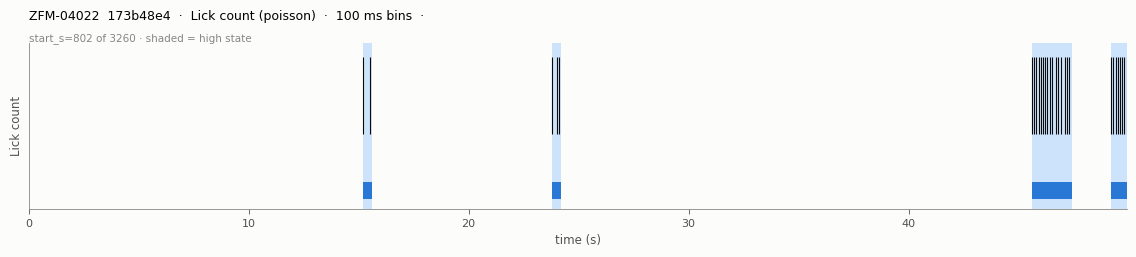

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

2130575d-5834-42c0-b4c9-c195cba80cb8


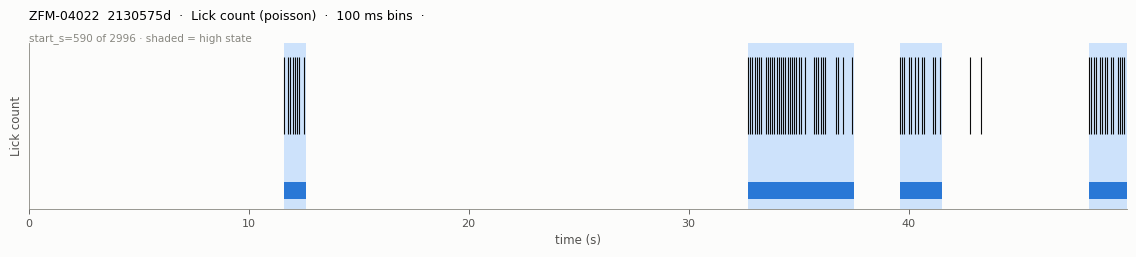

3dffc578-3fa8-4d01-b0df-a61a5593be46


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

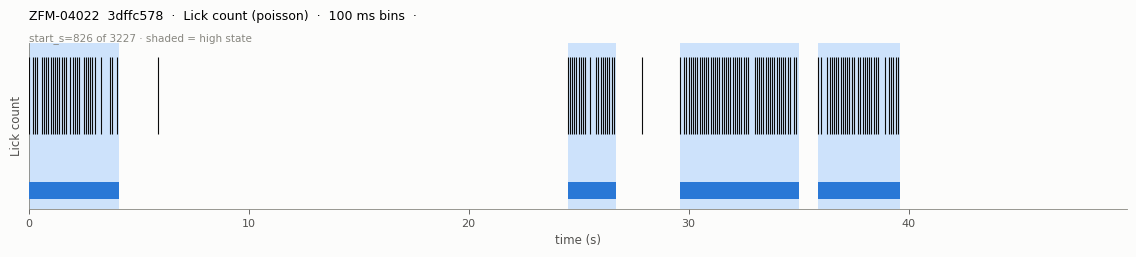

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

45335143-4cdb-4f55-bda3-3d2046b6b7e7


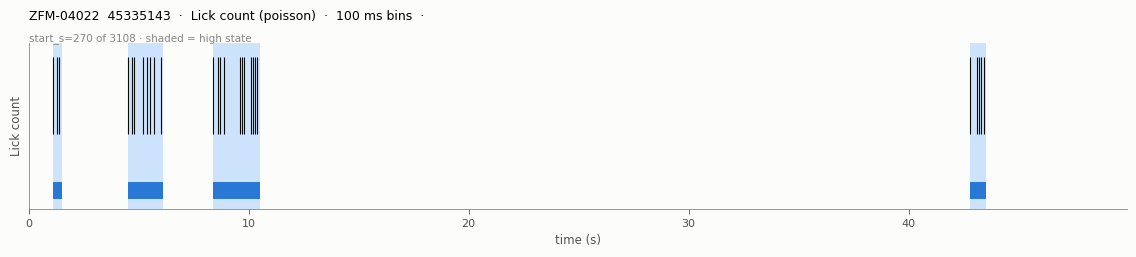

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

65f90bf6-5124-430a-ab73-134ac6fb374f


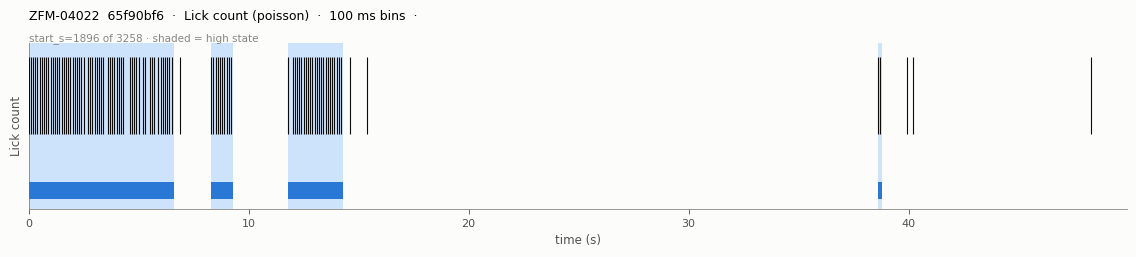

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

820790a2-7ae5-4daa-8871-e8e55d0a317d


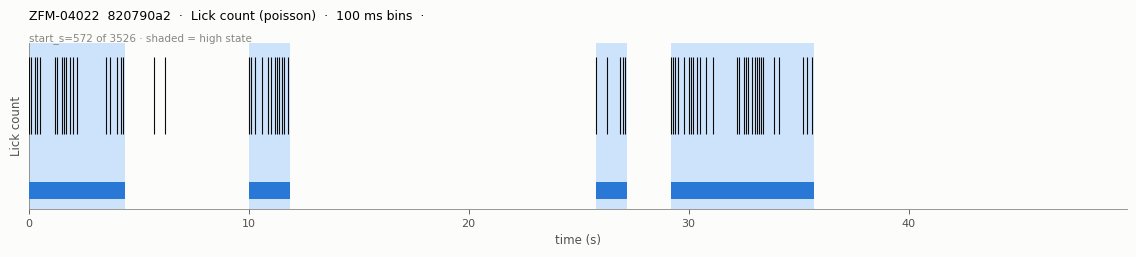

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

9c37c6e0-9bf0-4bde-b79a-4d6e95886350


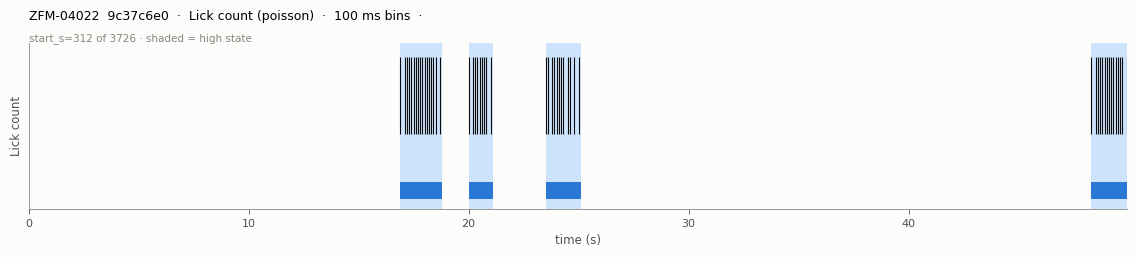

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

a1ccc8ed-9829-4af8-91fd-cc1c83b74b98


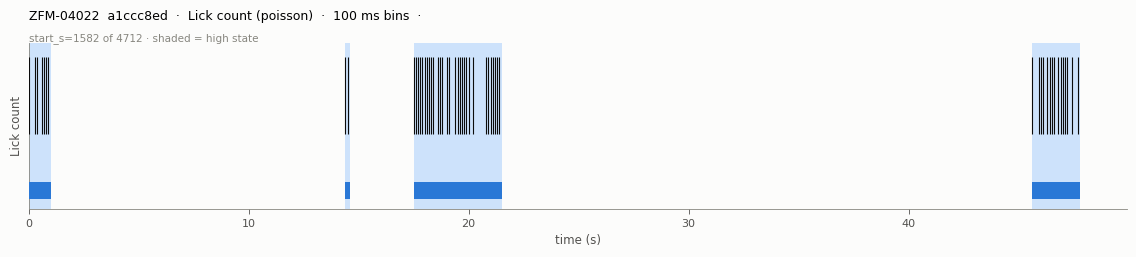

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

bc7a39b5-0e99-41e0-ba01-03a1380e1237


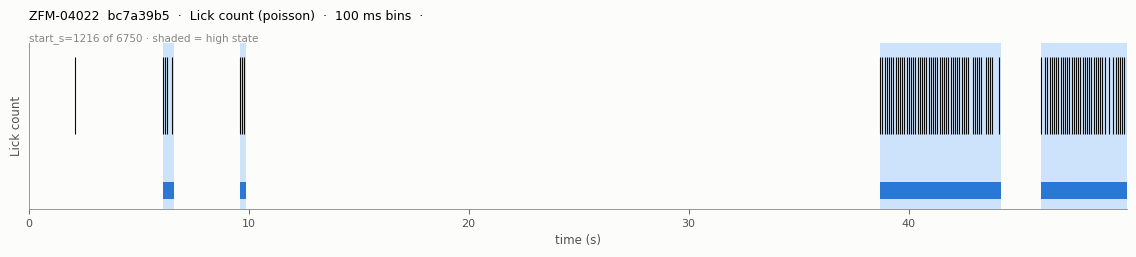

f0ebdfe3-15dd-4f71-b35e-aea6400b2b8b


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

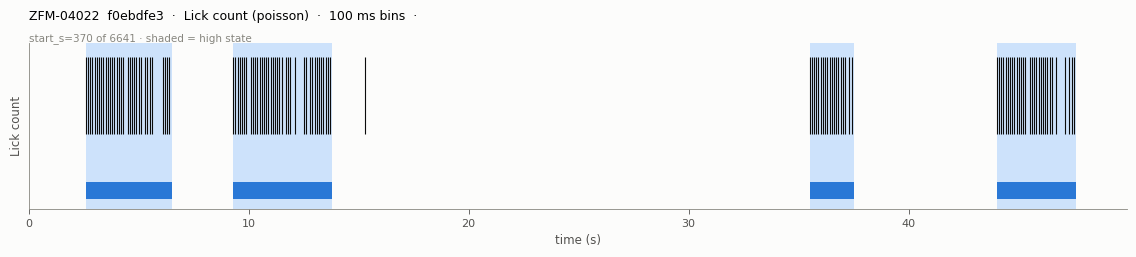

f930de5b-41d4-4bd7-9a54-8ae4f81b99f7


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

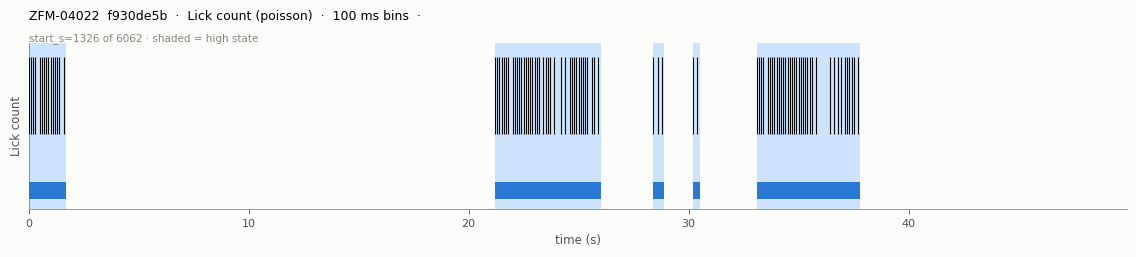

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

296c7e55-e338-43f2-b5bb-2ad6e0c52436


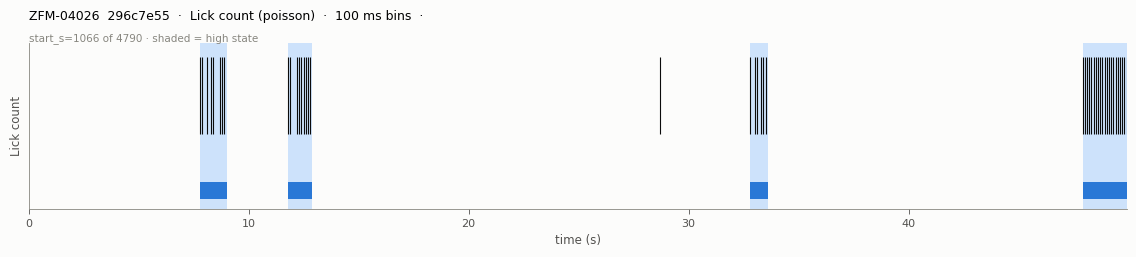

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

78bbffca-cd76-4f00-9c73-9dc2a528ac62


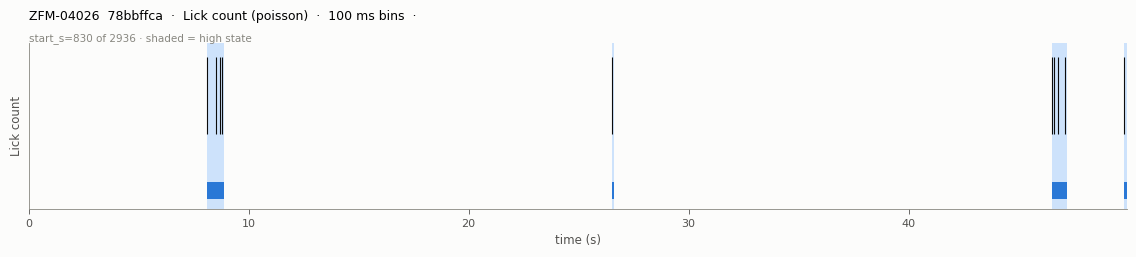

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

8af59882-3b50-4f1b-873c-46040587775b


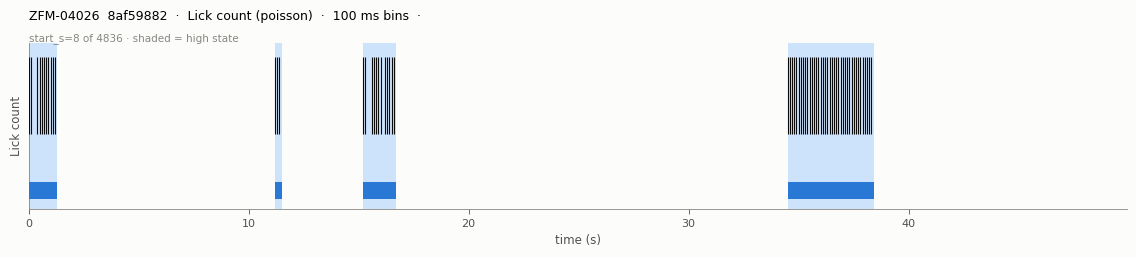

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

990aff49-5e4b-4b75-a597-3b4dd3b29720


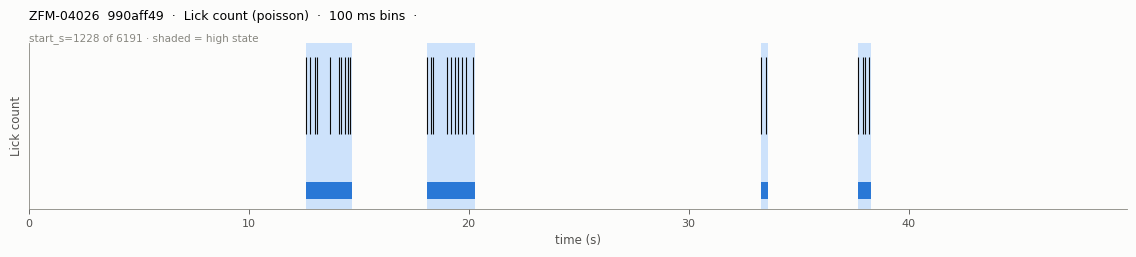

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

d2c9b9c1-28e1-47db-a165-54f822ba6c30


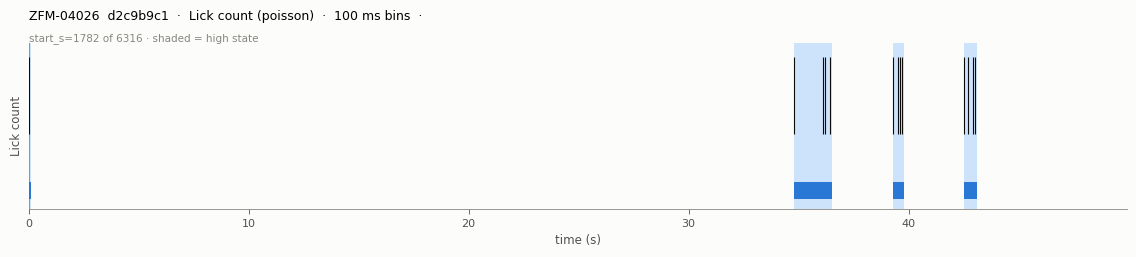

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

1b3db3e1-9777-4ad5-80e9-703c87550ad2


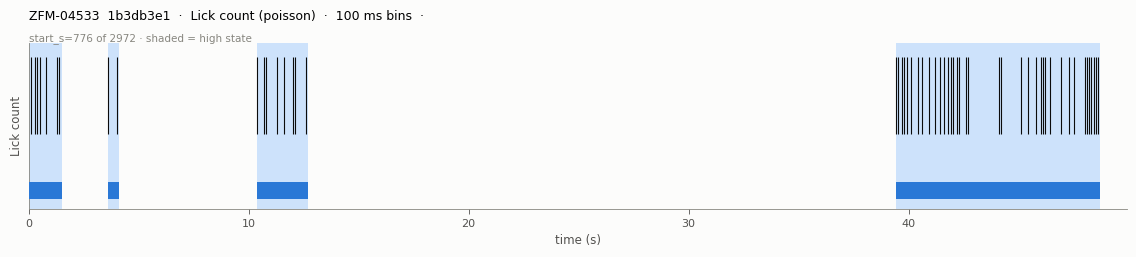

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

4ac35324-a13c-4517-a61f-7183a2f6ff44


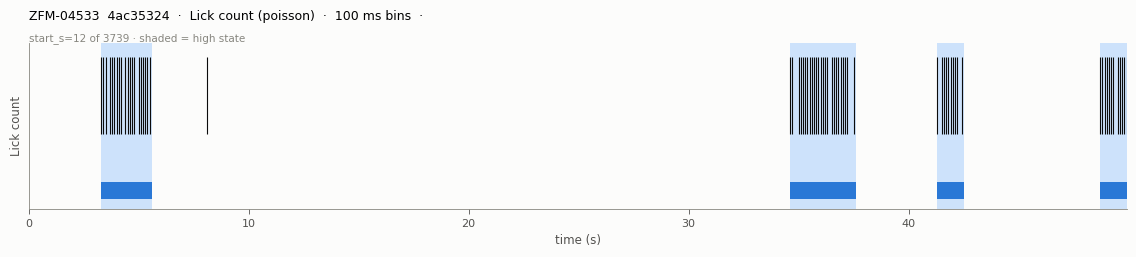

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

5782c52f-81dc-403f-bb94-4f39dc4a92a3


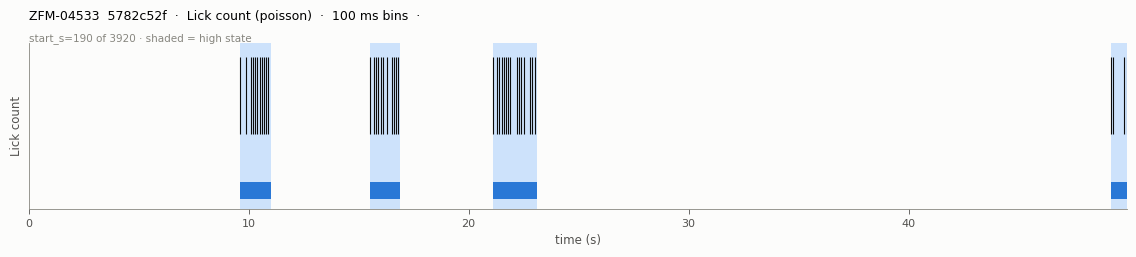

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

eafc9110-276d-4a55-8f23-5e21de257344


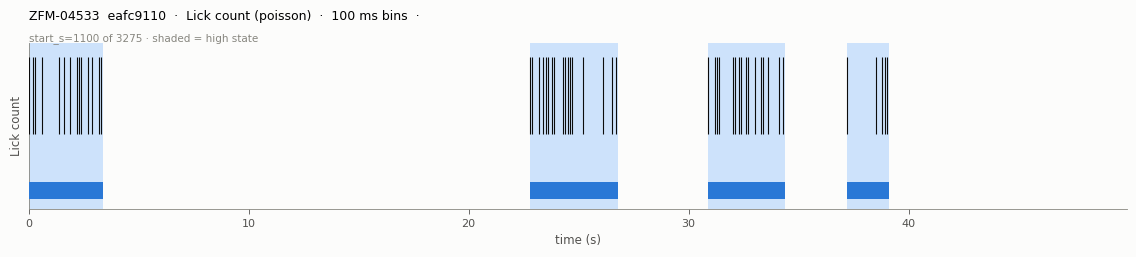

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

51678022-d298-475a-a740-3e46a2159424


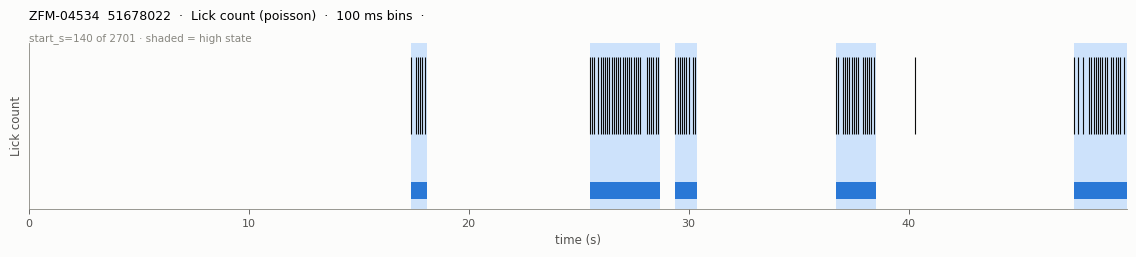

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

52227728-b958-4136-9c36-3865a855c1b4


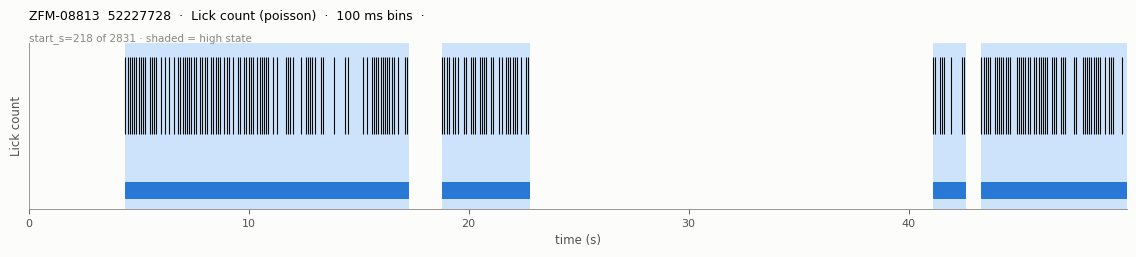

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

53ea983b-cdc0-4ce5-af49-70a70cab69db


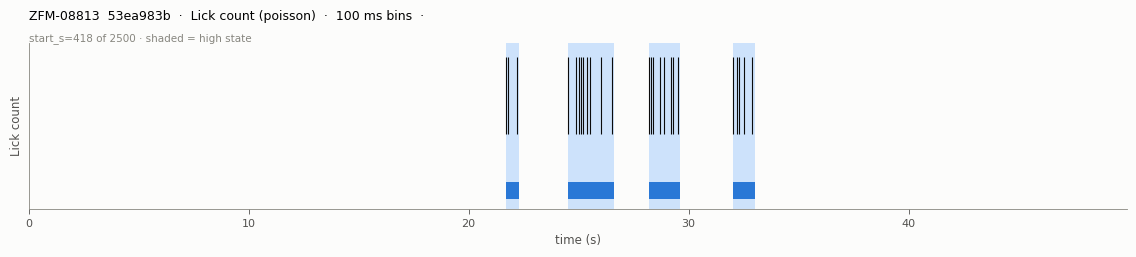

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

88ed4489-9031-4837-9581-63ac9c277ef5


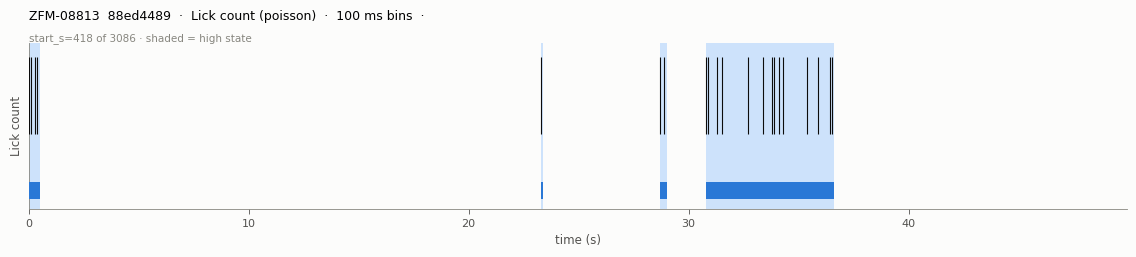

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

c0daba87-9960-4923-b4fa-792aea28f339


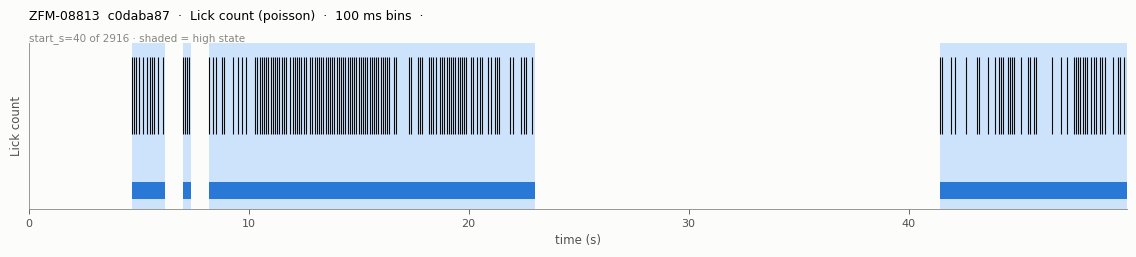

fdb324db-ec9c-45cc-b968-bbd416c11b4b


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

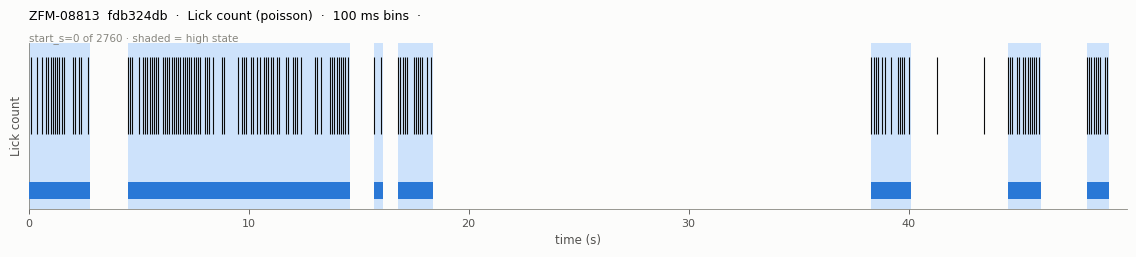

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

efcfbe24-c66b-4e94-a6b9-20f13b063236


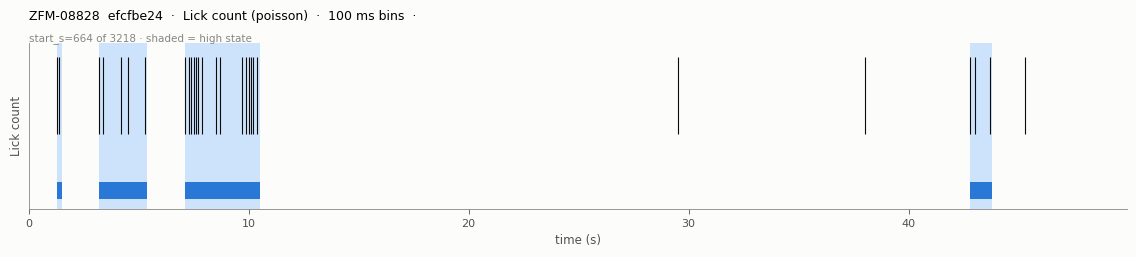

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

fc1f73f4-8b7e-4eb0-a7a8-cdfdd5eed22c


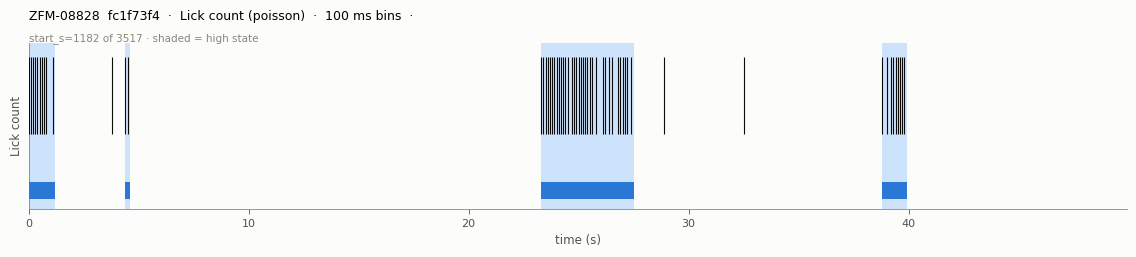

2cc16da0-6b81-46da-9ff0-93445d7539af


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

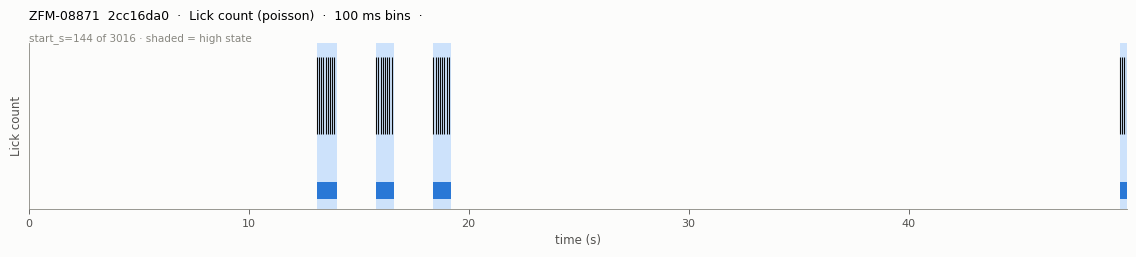

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

4278a70e-a04e-49c8-84a9-c961a163df21


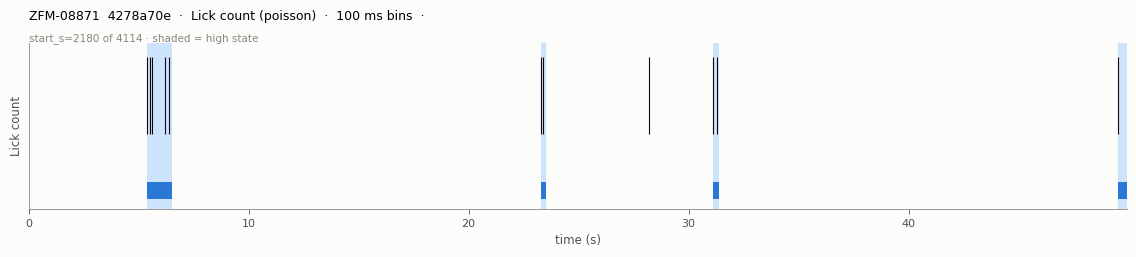

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

4ea8ba95-da8a-411c-a1d0-e9e094d13847


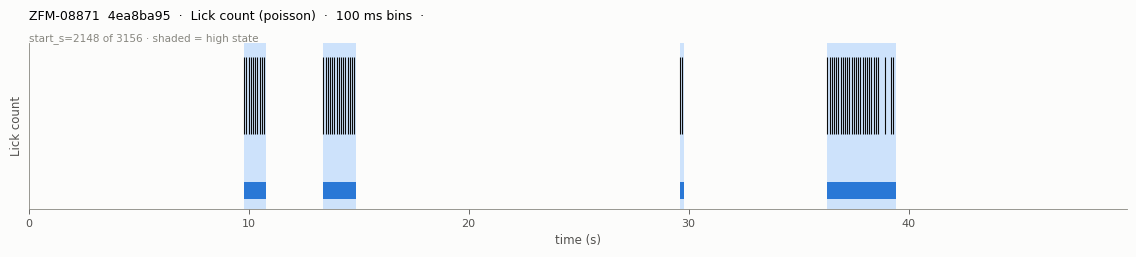

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

62a85c79-9c19-488b-9c75-a95728dad6ba


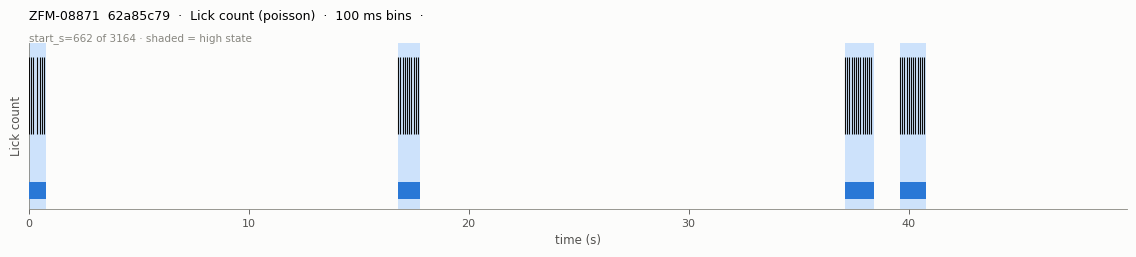

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

652dc8e5-0a09-41c0-9fdb-6ee8cca00f7c


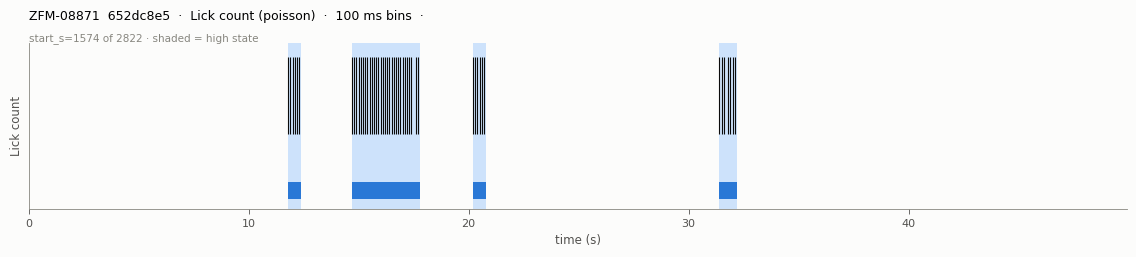

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

8911ecc7-5ba5-4432-b615-4a5721c86521


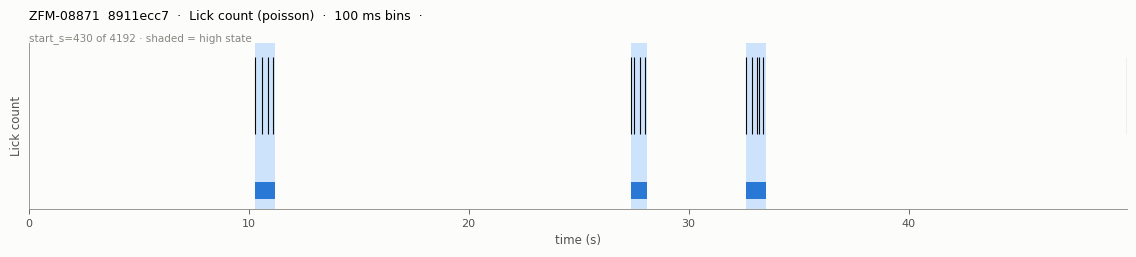

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

9cf5e2d0-4f64-4c1d-bb40-d79c04803b05


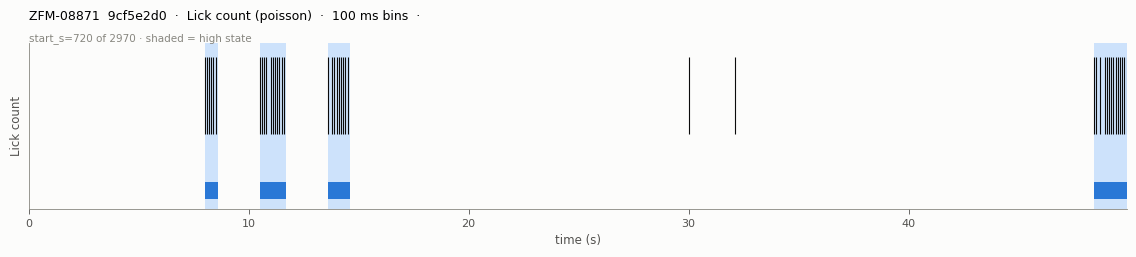

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

b0299fa3-648c-4d6c-9865-f39dd38f6239


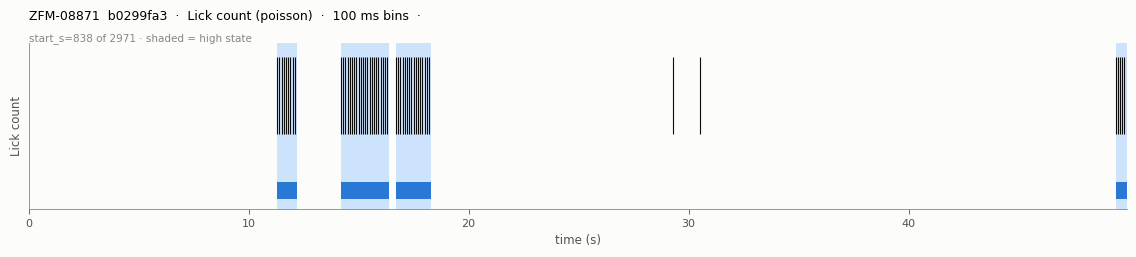

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

e365465e-21d3-40aa-ad6e-531221ac701e


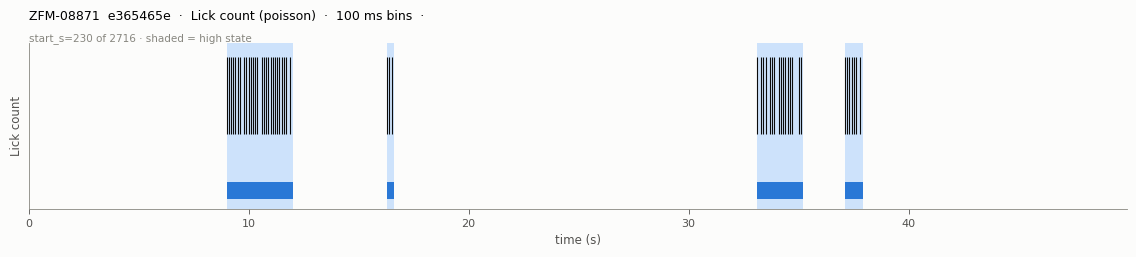

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

e3cf2e13-1748-4037-bce8-c47ce3b25f76


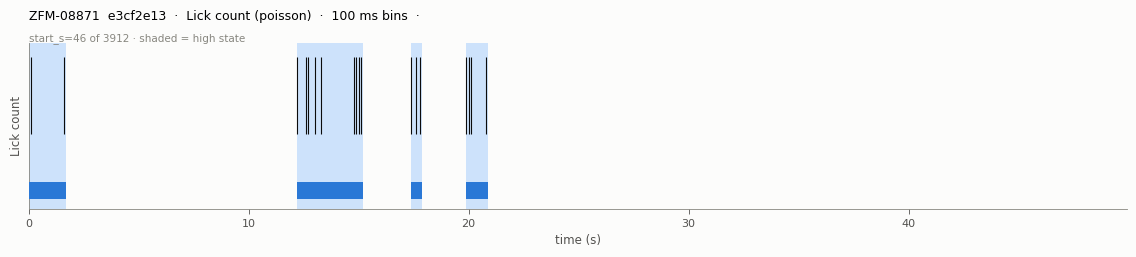

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

f2343157-4824-4fa2-84c1-a8bfebe21a8f


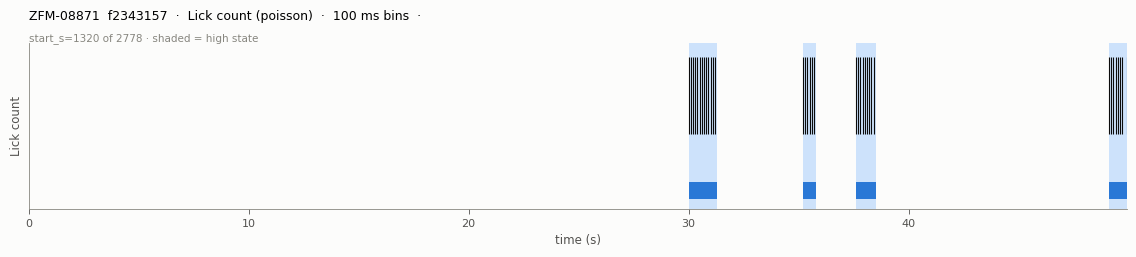

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

017ff9dd-85ae-4cfe-bb19-74277d537240


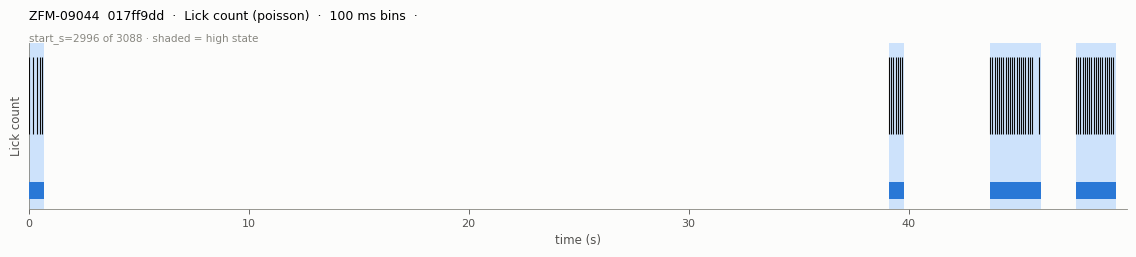

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

8582b879-2395-49be-afc1-41d7981378d4


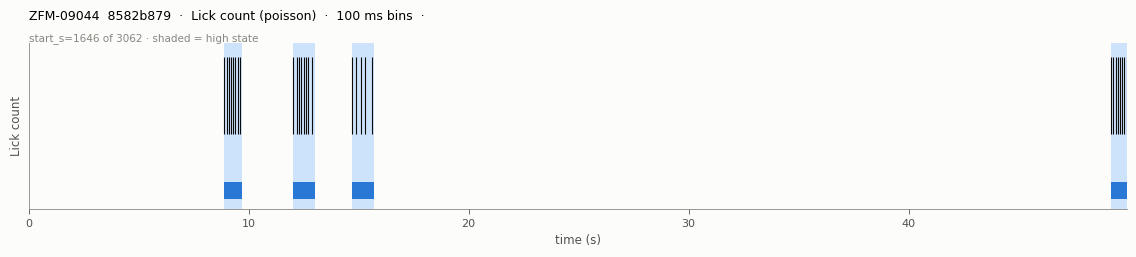

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

aa6fcf77-f8a0-446b-b980-ff390697a274


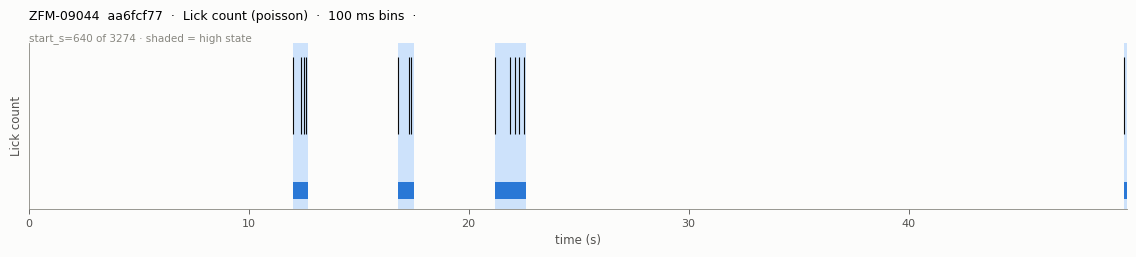

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

26c47ad4-24fe-4b4e-b176-5c7b257bcc73


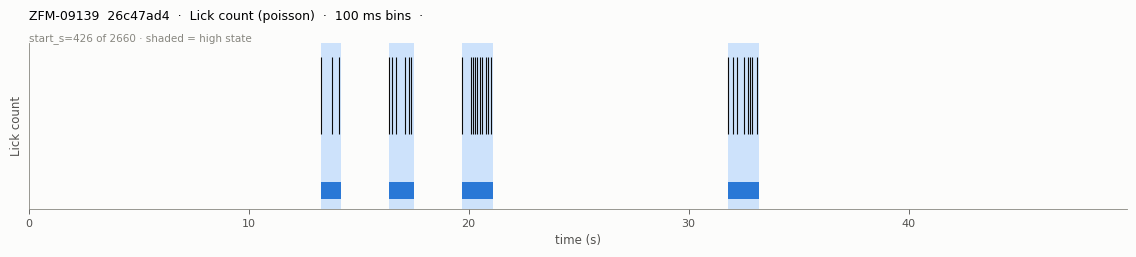

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

71510f8e-5c57-4411-9051-61db44889307


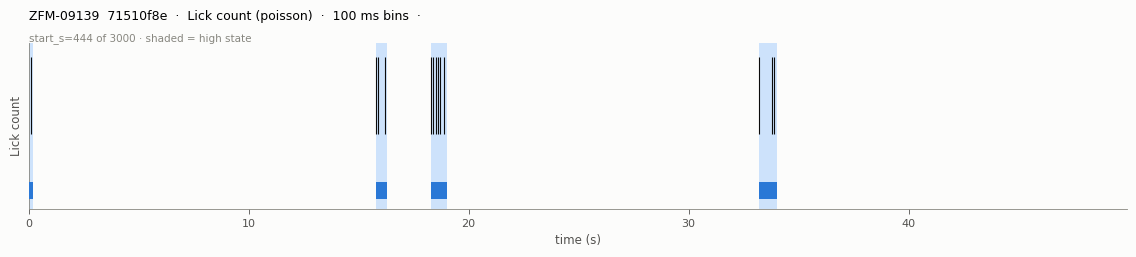

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

c49a7565-f87e-4b1d-9df4-7e187e842cbe


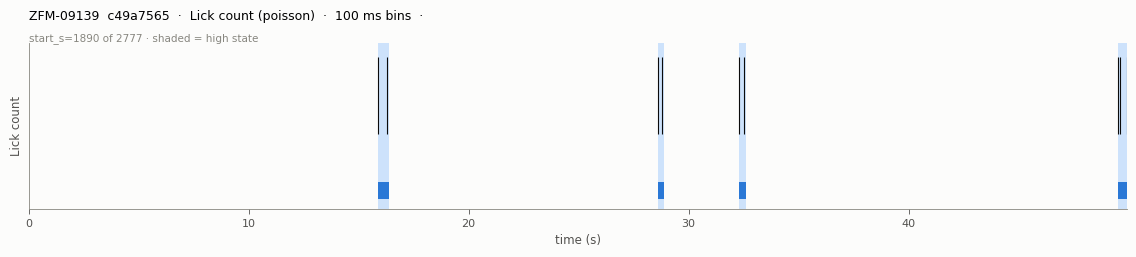

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

3b2a0c6c-d5b3-41c7-9bad-ebbf0b80751e


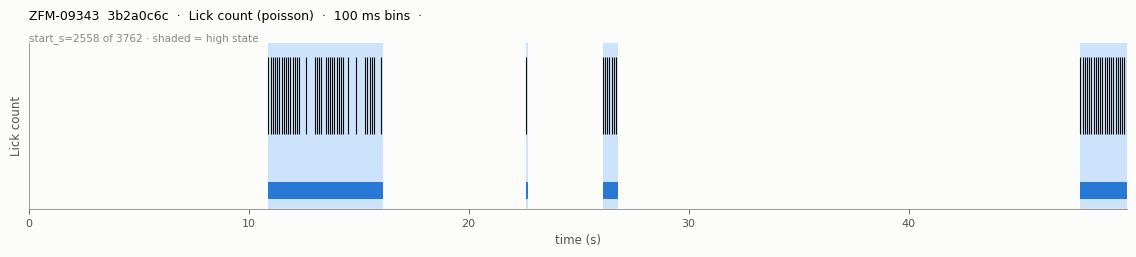

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

604dc7eb-533f-4d32-a1a3-064f7144656e


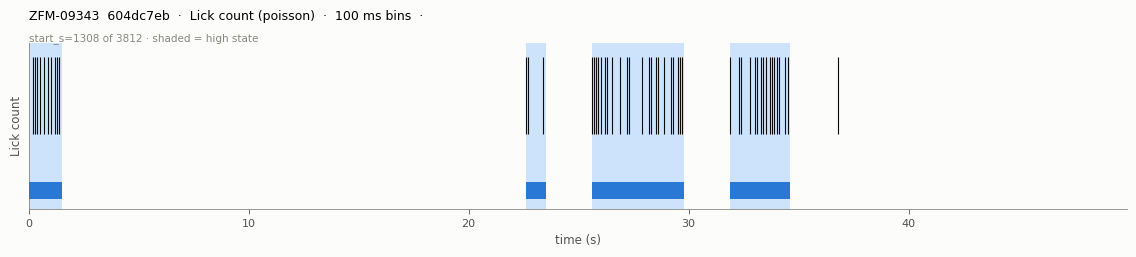

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

83cb0ac0-187c-4a80-b4ec-3efd5a5b45fd


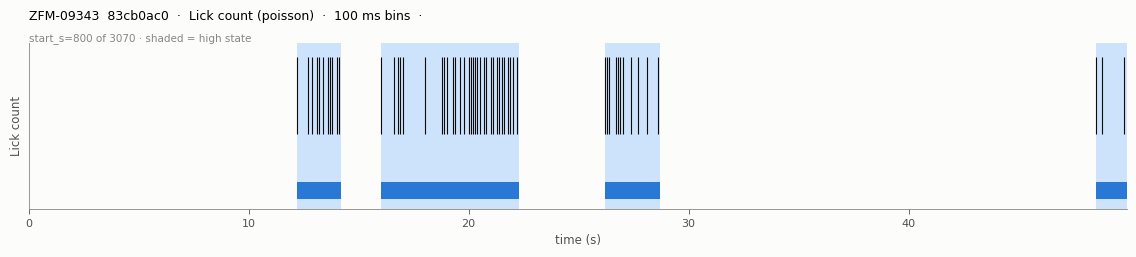

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

93f686ea-4eac-4416-aba1-a9f71c363e33


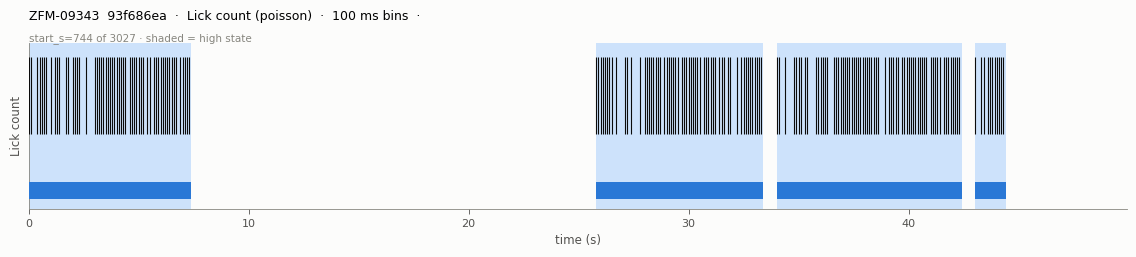

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

a9456015-4533-4bfa-bf6f-451d10fbcc53


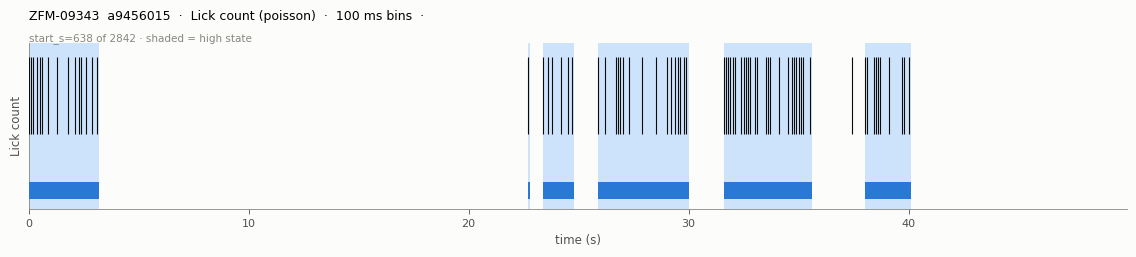

c3a09552-9c20-429f-a010-742de618a6bc


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

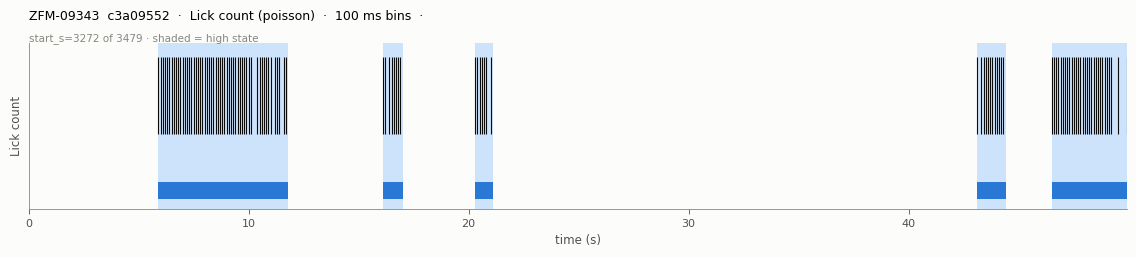

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

11dd167c-a607-4919-bda9-73fb7b030f7a


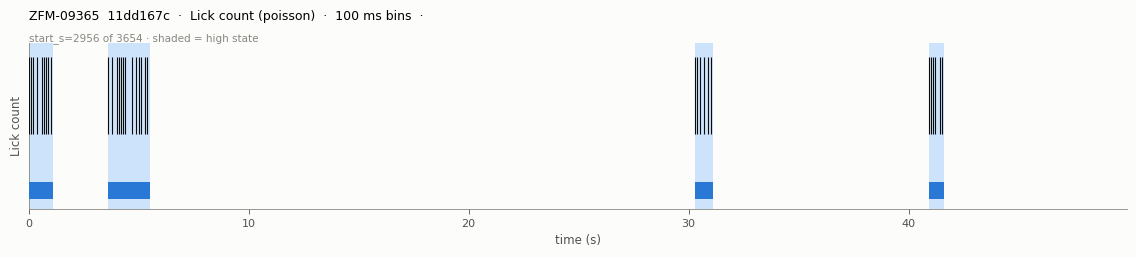

a3a3c3f1-78c3-4dda-ad25-59184989ed1f


/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

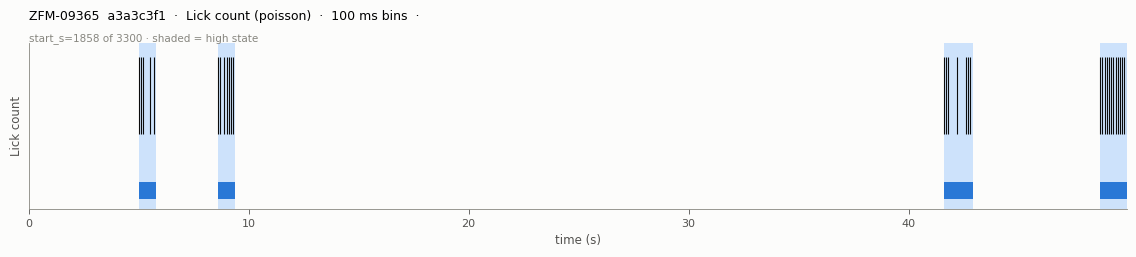

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

b0c3e683-0f49-4bee-bcd0-ea3b002502ed


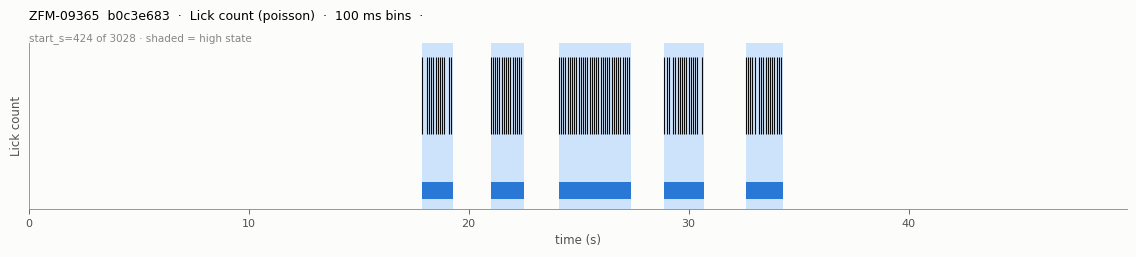

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

23331e9c-19fd-48b5-8634-13dbf2385ada


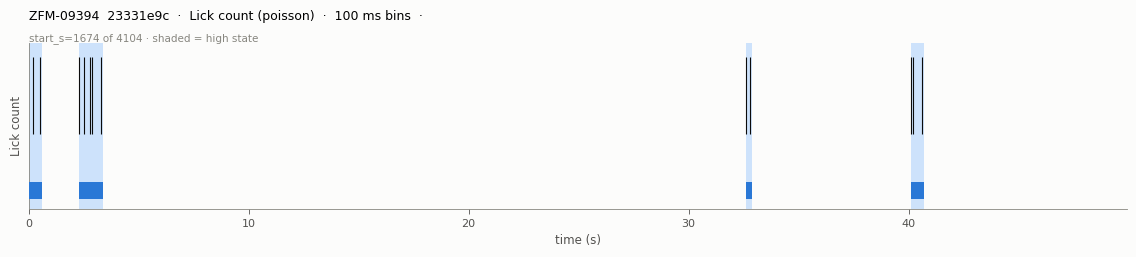

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

467e35a9-3d4e-4046-9996-a38c2ed1dfdf


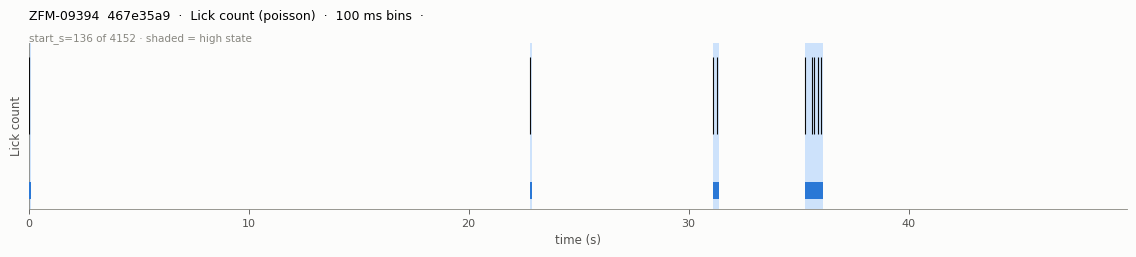

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

4e0dba79-b4df-4146-a4e8-634b6d7f43cd


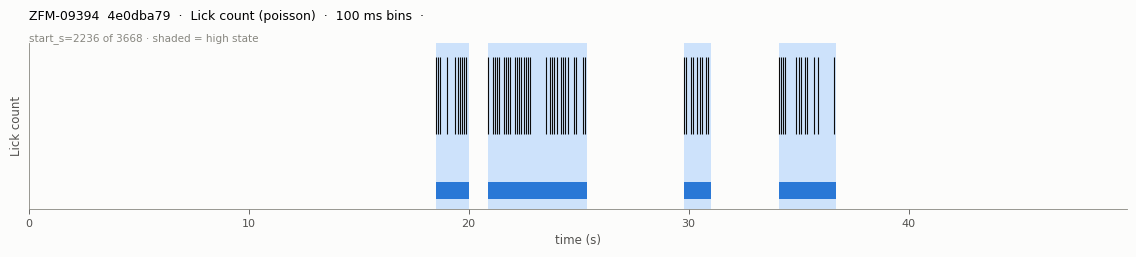

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

740e8d96-07cd-452a-b0e8-9a9b86a617d7


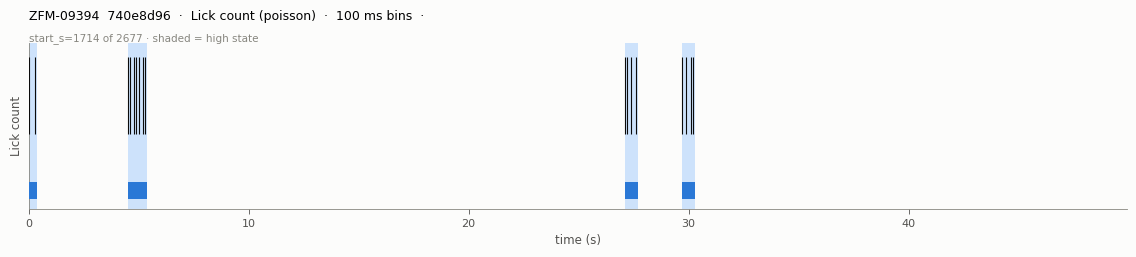

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

754f8a6b-60ef-480a-9665-5b3428aea365


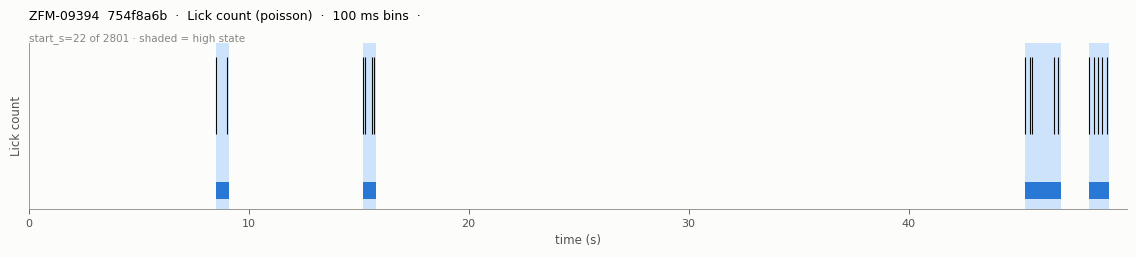

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

7c7a3a48-7c36-467d-92a7-f7ccd3a83544


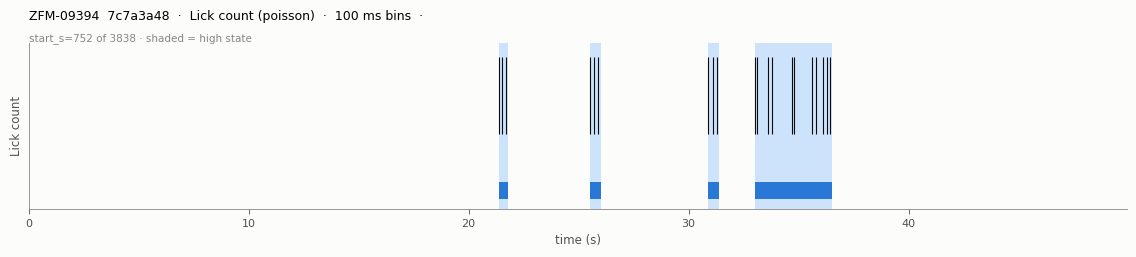

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

b121d132-050e-446c-9f62-09c460734471


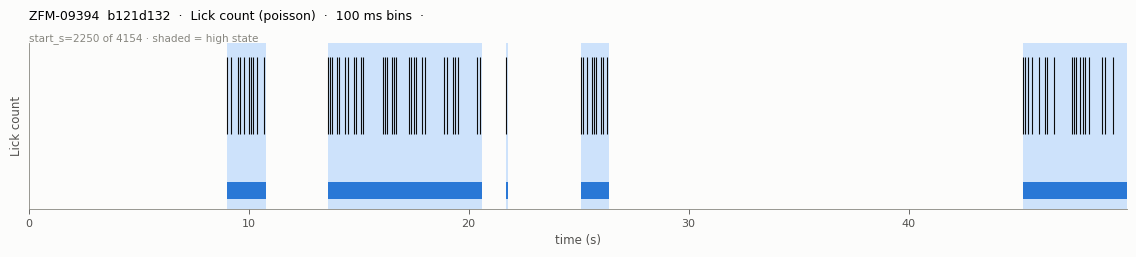

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

dc1c7c39-ae42-4304-a46b-f36c39ee8299


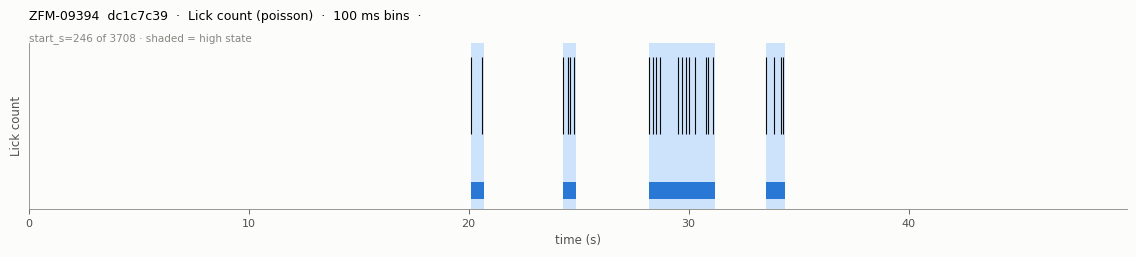

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

f3750246-503c-4b66-bf65-929f38944dca


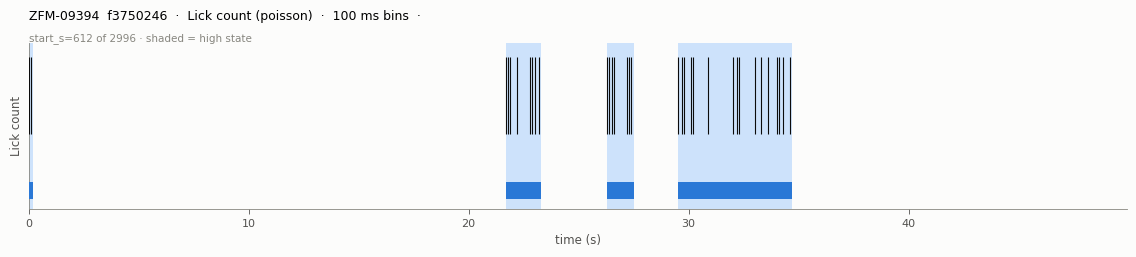

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

f6cd064d-ee3d-442f-9f06-971040b901dd


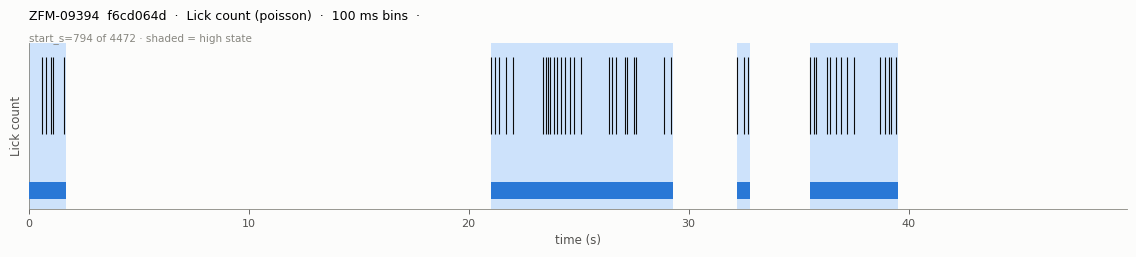

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

17563198-0121-40b7-ab81-f8393cbadb6a


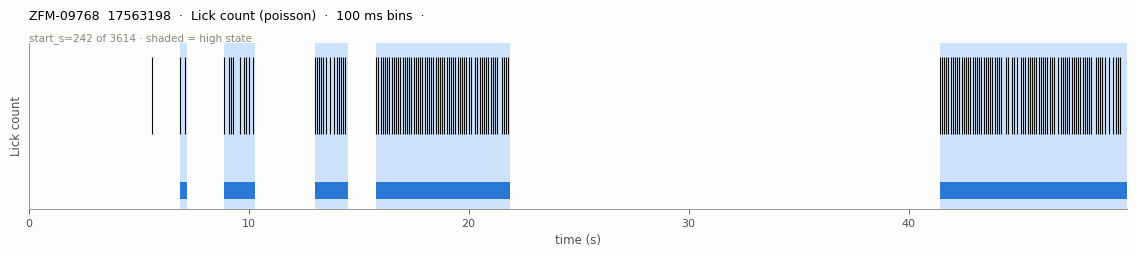

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

3b55dd6c-3708-4657-898a-93de1660019e


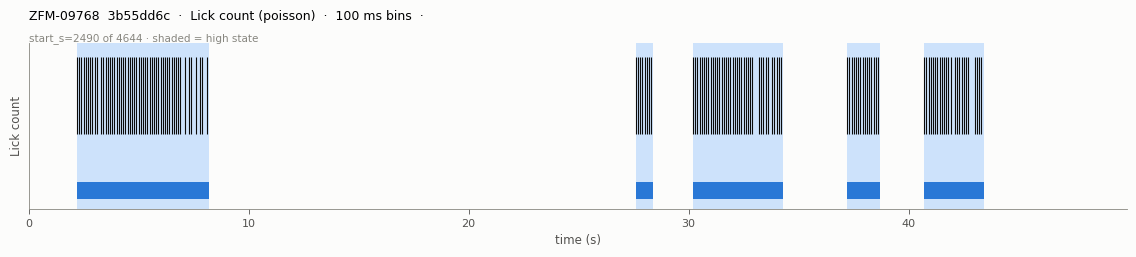

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

a57d5676-8836-4940-97e2-e4cd1a44976a


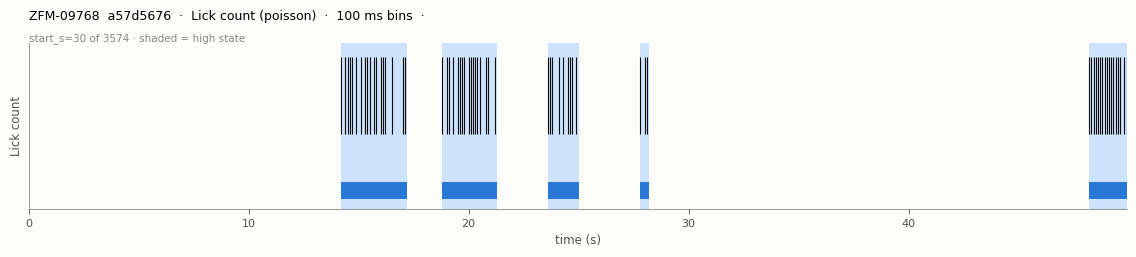

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

f4df73a0-2758-4eaf-9666-1e71b13cf95c


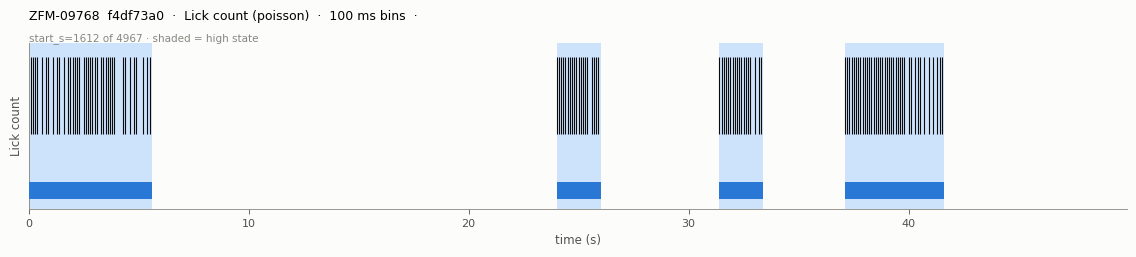

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

5bec164a-3eae-4097-9992-a99c62201d53


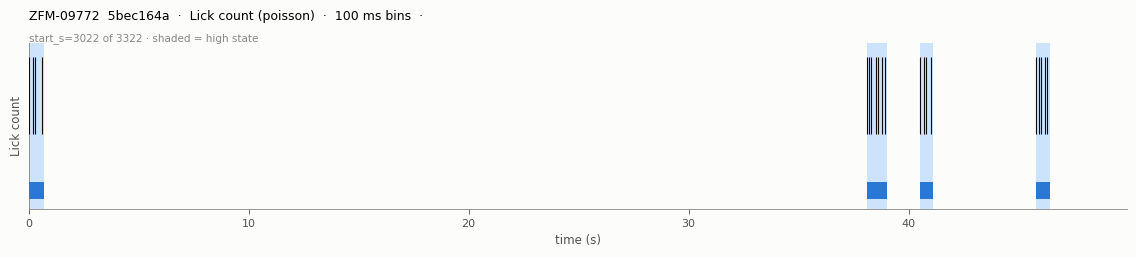

/home/ines/repositories/representation_learning_variability/paper-individuality/segmentation/hmm_functions.py:149: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[var].iloc[cut_idx:] = np.nan
/home/ines/repositories/representation_learning_

c55e4b10-1bd8-4bbc-97bf-fe1b6467e946


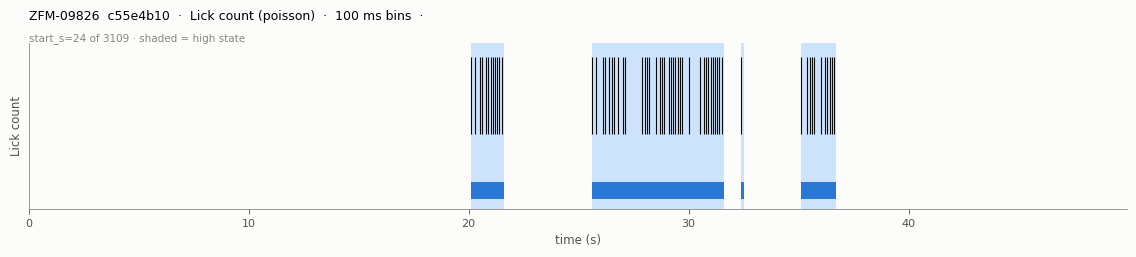

In [23]:
only_flagged = False
n_show = 350
win_s = 50
start_s = None

to_show = (df[~df.fit_ok] if only_flagged else df).head(n_show)
# to_show = to_show.loc[to_show['mouse']=='CSH_ZAD_019']

print(f'showing {len(to_show)} of {len(df)}')
for _, r in to_show.iterrows():
    try:
        fig, d = P.plot_session(save_path, data_path, var,
                                mouse_name=r['mouse'], session=r['eid'],
                                num_train_batches=num_train_batches, fps=fps,
                                win_s=win_s, start_s=start_s)
        print(r['eid'])
        plt.show()
    except FileNotFoundError as e:
        print(f"{r['mouse']} {r['eid'][:8]}: {e}")

## Compare the two variables on the same session

Whisking and licking segmented independently, on the same time axis — useful for sanity
(licking bouts should sit inside or beside whisking bouts, not at random).

In [ ]:
eid_both = df.iloc[0]['eid']

for spec_i in VARIABLES:
    sp, _ = paths_for(spec_i)
    try:
        fig, d = P.plot_session(sp, data_path, spec_i['var'], eid=eid_both,
                                num_train_batches=num_train_batches, fps=fps,
                                win_s=20, start_s=start_s)
        plt.show()
    except FileNotFoundError:
        print(f"{spec_i['var']}: not fitted for this session")